## Arquitectura Principal: Clase `OneDBioPINN`
Este bloque de código define el núcleo matemático y computacional del modelo. La clase `OneDBioPINN` (Red Neuronal Informada por la Física para Biología 1D) se encarga de construir la red, aplicar las leyes de la física y gestionar el entrenamiento. Se utiliza la compatibilidad con TensorFlow 1.x para manejar los grafos computacionales y los marcadores de posición (*placeholders*).

---

### 1. Inicialización y Adimensionalización
El método `__init__` es el constructor de la clase. Sus tareas principales son:
* **Definición de constantes físicas:** Establece la densidad de la sangre, las áreas transversales iniciales y los parámetros de rigidez arterial de los vasos.
* **Adimensionalización:** Como las variables biológicas tienen escalas muy diferentes (presiones enormes frente a áreas microscópicas), el modelo calcula factores de escala para la longitud, el tiempo y la velocidad. Esto normaliza los datos de entrada para evitar el colapso matemático durante el entrenamiento.
* **Preparación de tensores:** Convierte los datos de entrenamiento y los puntos de evaluación en estructuras de TensorFlow listas para el cálculo.

---

### 2. Arquitectura de la Red Neuronal
Los métodos `initialize_NN`, `xavier_init` y `neural_net` construyen el "cerebro" del modelo:
* **Inicialización Xavier:** Se utiliza para asignar los pesos iniciales de las neuronas de forma óptima, evitando que los gradientes se desvanezcan prematuramente.
* **Salidas del modelo:** Para cada uno de los tres vasos sanguíneos, la red predice tres valores fundamentales: Área transversal, Velocidad y Presión.
> **Nota técnica:** El área transversal se calcula utilizando una función exponencial para garantizar matemáticamente que el área predicha siempre sea un valor positivo.

---

### 3. Las Leyes de la Física (Función de Pérdida)
Esta es la diferencia crucial entre una red neuronal tradicional y una PINN. La IA penaliza sus propios errores basándose en tres principios físicos:
* **Pérdida de Interfaz (`compute_interface_loss`):** En el punto de bifurcación, asegura la conservación de la masa (el caudal que entra al vaso 1 debe ser igual al que sale por los vasos 2 y 3, formulado como $Q_1 - Q_2 - Q_3 = 0$) y la continuidad del momento (presión dinámica).
* **Pérdida Residual (`pinn_vessel`):** Obliga a las predicciones a respetar las ecuaciones diferenciales parciales de Navier-Stokes 1D para fluidos.
* **Pérdida de Medición (`compute_measurement_loss`):** Compara las predicciones de la red con los datos de entrada reales para garantizar que el modelo no solo respete la física, sino que también se ajuste a la realidad del paciente.

---

### 4. Entrenamiento y Predicción
Finalmente, el modelo se optimiza y se pone a prueba:
* **Entrenamiento (`train`):** Utiliza el optimizador Adam para minimizar la función de pérdida total (la suma de las pérdidas físicas y de medición). Emplea "mini-batches" aleatorios para hacer el entrenamiento más rápido y eficiente, imprimiendo el progreso en pantalla.
* **Inferencia (`predict_vessel`):** Una vez que la red está entrenada, estos métodos toman nuevos puntos de tiempo y espacio, los normalizan, pasan por la red neuronal y luego devuelven las predicciones escaladas a sus unidades físicas reales (metros y Pascales).

In [ ]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import timeit


class OneDBioPINN:
    # Initialize the class
    def __init__(self, X_measurement_vessel1,
                               X_measurement_vessel2,
                               X_measurement_vessel3,
                               A_training_vessel1,  U_training_vessel1,
                               A_training_vessel2,  U_training_vessel2,
                               A_training_vessel3,  U_training_vessel3,
                               X_residual_vessel1,
                               X_residual_vessel2,
                               X_residual_vessel3,
                               T_residual, T_measurement, layers, bif_points):

        self.A_01 = 1.35676200E-05
        self.A_02 = 1.81458400E-06
        self.A_03 = 1.35676200E-05

        self.rho = 1000.
        self.beta1 =  69673881.97
        self.beta2 =  541788704.42
        self.beta3 =  69549997.97

        self.U = 1e+1

        self.L = np.sqrt(0.333*(self.A_01 + self.A_02 + self.A_03))
        self.T = self.L/self.U
        self.p0 = self.rho*self.U**2

        self.A0 = self.L**2

        X_measurement_vessel1 = X_measurement_vessel1/self.L
        X_measurement_vessel2 = X_measurement_vessel2/self.L
        X_measurement_vessel3 = X_measurement_vessel3/self.L

        X_residual_vessel1 = X_residual_vessel1/self.L
        X_residual_vessel2 = X_residual_vessel2/self.L
        X_residual_vessel3 = X_residual_vessel3/self.L

        T_residual  = T_residual/self.T
        T_measurement  = T_measurement/self.T

        # Normalize inputs
        self.Xmean1, self.Xstd1 = X_residual_vessel1.mean(0), X_residual_vessel1.std(0)
        self.Xmean2, self.Xstd2 = X_residual_vessel2.mean(0), X_residual_vessel2.std(0)
        self.Xmean3, self.Xstd3 = X_residual_vessel3.mean(0), X_residual_vessel3.std(0)

        self.Tmean, self.Tstd = T_residual.mean(0), T_residual.std(0)

        self.jac_x1 = 1.0/self.Xstd1
        self.jac_x2 = 1.0/self.Xstd2
        self.jac_x3 = 1.0/self.Xstd3

        self.jac_t = 1.0/self.Tstd


        self.X_f1 = (X_residual_vessel1 - self.Xmean1)/self.Xstd1
        self.X_u1 = (X_measurement_vessel1 - self.Xmean1)/self.Xstd1

        self.X_f2 = (X_residual_vessel2 - self.Xmean2)/self.Xstd2
        self.X_u2 = (X_measurement_vessel2 - self.Xmean2)/self.Xstd2

        self.X_f3 = (X_residual_vessel3 - self.Xmean3)/self.Xstd3
        self.X_u3 = (X_measurement_vessel3 - self.Xmean3)/self.Xstd3


        self.T_u = (T_measurement - self.Tmean)/self.Tstd
        self.T_f = (T_residual - self.Tmean)/self.Tstd

        self.layers = layers

        self.A_u1 = A_training_vessel1
        self.u_u1 = U_training_vessel1

        self.A_u2 = A_training_vessel2
        self.u_u2 = U_training_vessel2

        self.A_u3 = A_training_vessel3
        self.u_u3 = U_training_vessel3

        X1_fm = bif_points/self.L
        X2_fm = bif_points/self.L
        X3_fm = bif_points/self.L

        bif_p1 = (X1_fm - self.Xmean1)/self.Xstd1
        bif_p2 = (X2_fm - self.Xmean2)/self.Xstd2
        bif_p3 = (X3_fm - self.Xmean3)/self.Xstd3

        X1max = bif_p1[0]
        X2min = bif_p2[0]
        X3min = bif_p3[0]

        # Initialize network weights and biases
        self.weights1, self.biases1 = self.initialize_NN(layers)
        self.weights2, self.biases2 = self.initialize_NN(layers)
        self.weights3, self.biases3 = self.initialize_NN(layers)

        # Define placeholders and computational graph
        self.learning_rate = tf.placeholder(tf.float32, shape=[])

        self.X1_fm = tf.constant([X1max], shape = [1024,1], dtype=tf.float32)
        self.X2_fm = tf.constant([X2min], shape = [1024,1], dtype=tf.float32)
        self.X3_fm = tf.constant([X3min], shape = [1024,1], dtype=tf.float32)

        self.t_bound = tf.placeholder(tf.float32, shape=(None, self.T_f.shape[1]), name='self.t_bound')

        self.A_u_tf1 = tf.placeholder(tf.float32, shape=(None, self.A_u1.shape[1]),name= 'self.A_u_tf1')
        self.u_u_tf1 = tf.placeholder(tf.float32, shape=(None, self.u_u1.shape[1]), name='self.u_u_tf1')

        self.A_u_tf2 = tf.placeholder(tf.float32, shape=(None, self.A_u2.shape[1]),name= 'self.A_u_tf2')
        self.u_u_tf2 = tf.placeholder(tf.float32, shape=(None, self.u_u2.shape[1]), name='self.u_u_tf2')

        self.A_u_tf3 = tf.placeholder(tf.float32, shape=(None, self.A_u3.shape[1]), name='self.A_u_tf3')
        self.u_u_tf3 = tf.placeholder(tf.float32, shape=(None, self.u_u3.shape[1]), name='self.u_u_tf3')

        self.X_u_tf1 = tf.placeholder(tf.float32, shape=(None, self.X_u1.shape[1]),name= 'self.X_u_tf1')
        self.X_u_tf2 = tf.placeholder(tf.float32, shape=(None, self.X_u2.shape[1]),name= 'self.X_u_tf2')
        self.X_u_tf3 = tf.placeholder(tf.float32, shape=(None, self.X_u3.shape[1]), name='self.X_u_tf3')

        self.t_u_tf = tf.placeholder(tf.float32,  shape=(None, self.T_u.shape[1]), name='self.t_u_tf')

        self.X_f_tf1 = tf.placeholder(tf.float32, shape=(None, self.X_f1.shape[1]),name= 'self.X_f_tf1')
        self.X_f_tf2 = tf.placeholder(tf.float32, shape=(None, self.X_f2.shape[1]),name= 'self.X_f_tf2')
        self.X_f_tf3 = tf.placeholder(tf.float32, shape=(None, self.X_f3.shape[1]), name='self.X_f_tf3')

        self.t_f_tf = tf.placeholder(tf.float32, shape=(None, self.T_f.shape[1]), name='self.t_f_tf')

        self.A_u_pred1, self.u_u_pred1, _  = self.neural_net_vessel1(self.X_u_tf1, self.t_u_tf)
        self.A_u_pred2, self.u_u_pred2, _  = self.neural_net_vessel2(self.X_u_tf2, self.t_u_tf)
        self.A_u_pred3, self.u_u_pred3, _  = self.neural_net_vessel3(self.X_u_tf3, self.t_u_tf)

        self.A_f_pred1, self.u_f_pred1, self.p_f_pred1  = self.neural_net_vessel1(self.X_f_tf1, self.t_f_tf)
        self.A_f_pred2, self.u_f_pred2, self.p_f_pred2  = self.neural_net_vessel2(self.X_f_tf2, self.t_f_tf)
        self.A_f_pred3, self.u_f_pred3, self.p_f_pred3  = self.neural_net_vessel3(self.X_f_tf3, self.t_f_tf)

        self.r_A1, self.r_u1, self.r_p1  = self.pinn_vessel1(self.X_f_tf1, self.t_f_tf)
        self.r_A2, self.r_u2, self.r_p2  = self.pinn_vessel2(self.X_f_tf2, self.t_f_tf)
        self.r_A3, self.r_u3, self.r_p3  = self.pinn_vessel3(self.X_f_tf3, self.t_f_tf)

        self.loss_A1, self.loss_u1 = self.compute_measurement_loss_vessel1(self.A_u_pred1, self.u_u_pred1)
        self.loss_rA1, self.loss_ru1, self.loss_rp1 = self.compute_residual_loss_vessel1 (self.r_A1, self.r_u1, self.r_p1)

        self.loss_A2, self.loss_u2 = self.compute_measurement_loss_vessel2(self.A_u_pred2, self.u_u_pred2)
        self.loss_rA2, self.loss_ru2, self.loss_rp2 = self.compute_residual_loss_vessel2(self.r_A2, self.r_u2, self.r_p2)

        self.loss_A3, self.loss_u3 = self.compute_measurement_loss_vessel3(self.A_u_pred3, self.u_u_pred3)
        self.loss_rA3, self.loss_ru3, self.loss_rp3 = self.compute_residual_loss_vessel3(self.r_A3, self.r_u3, self.r_p3)

        self.loss_A = self.loss_A1 + self.loss_A2 + self.loss_A3

        self.loss_u = self.loss_u1 + self.loss_u2 + self.loss_u3

        self.loss_ru = self.loss_ru1 + self.loss_ru2 + self.loss_ru3

        self.loss_rA = self.loss_rA1 + self.loss_rA2 + self.loss_rA3

        self.loss_rp = self.loss_rp1 + self.loss_rp2 + self.loss_rp3

        self.loss_measurements = self.loss_A + self.loss_u

        self.loss_interface  = self.compute_interface_loss()

        self.loss_residual = self.loss_rA + self.loss_ru + self.loss_rp

        self.loss =  self.loss_residual + self.loss_interface + self.loss_measurements

        # Define optimizer
        self.optimizer  = tf.train.AdamOptimizer(self.learning_rate)

        self.train_op = self.optimizer.minimize(self.loss)
        config = tf.ConfigProto(log_device_placement=True)
        self.sess = tf.Session(config=config)
        init = tf.global_variables_initializer()

        self.sess.run(init)


    # Initialize network weights and biases using Xavier initialization
    def initialize_NN(self, layers):
        weights = []
        biases = []
        num_layers = len(layers)
        for l in range(0,num_layers-1):
            W = self.xavier_init(size=[layers[l], layers[l+1]])
            b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
            weights.append(W)
            biases.append(b)
        return weights, biases

    def xavier_init(self, size):
        in_dim = size[0]
        out_dim = size[1]
        xavier_stddev = np.sqrt(2/(in_dim + out_dim))
        return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32)


    def neural_net(self, H, weights, biases, layers):
        num_layers = len(layers)
        for l in range(0,num_layers-2):
            W = weights[l]
            b = biases[l]
            H = tf.tanh(tf.add(tf.matmul(H, W), b))
        W = weights[-1]
        b = biases[-1]
        Y = tf.add(tf.matmul(H, W), b)
        return Y

    def neural_net_vessel1(self, x, t):
        Au = self.neural_net(tf.concat([x,t],1),self.weights1,self.biases1,self.layers)
        A = Au[:,0:1]
        u = Au[:,1:2]
        p = Au[:,2:3]
        return tf.exp(A), u, p

    def neural_net_vessel2(self, x, t):
        Au = self.neural_net(tf.concat([x,t],1),self.weights2,self.biases2,self.layers)
        A = Au[:,0:1]
        u = Au[:,1:2]
        p = Au[:,2:3]
        return tf.exp(A), u, p

    def neural_net_vessel3(self, x, t):
        Au = self.neural_net(tf.concat([x,t],1),self.weights3,self.biases3,self.layers)
        A = Au[:,0:1]
        u = Au[:,1:2]
        p = Au[:,2:3]
        return tf.exp(A), u, p

    def compute_interface_loss(self):

         A1, u1, p1 = self.neural_net_vessel1(self.X1_fm,self.t_f_tf)

         A2, u2, p2 = self.neural_net_vessel2(self.X2_fm,self.t_f_tf)

         A3, u3, p3 = self.neural_net_vessel3(self.X3_fm,self.t_f_tf)

         Q1 = A1*u1
         Q2 = A2*u2
         Q3 = A3*u3

         loss_mass = tf.reduce_mean(tf.square((Q1 - Q2 - Q3)))

         p_1 = p1 + (0.5*u1**2)
         p_2 = p2 + (0.5*u2**2)
         p_3 = p3 + (0.5*u3**2)

         loss_momentum = tf.reduce_mean(tf.square( p_1 - p_2)) + tf.reduce_mean(tf.square( p_1 - p_3))


         return  loss_mass + loss_momentum

    def pinn_vessel1(self, x, t):

        A, u, p = self.neural_net_vessel1(x,t) # \hat{A}, \hat{u}, \hat{p}

        r_p  =  self.beta1*(tf.sqrt(A*self.A0) - tf.sqrt(self.A_01))

        p_x = tf.gradients(p, x)[0]*self.jac_x1

        A_t = tf.gradients(A, t)[0]*self.jac_t
        A_x = tf.gradients(A, x)[0]*self.jac_x1

        u_t = tf.gradients(u, t)[0]*self.jac_t
        u_x = tf.gradients(u, x)[0]*self.jac_x1

        r_A = A_t + u*A_x + A*u_x #r_A*
        r_u = u_t + p_x + u*u_x #r_u*

        return r_A, r_u, r_p

    def pinn_vessel2(self, x, t):

        A, u, p = self.neural_net_vessel2(x,t) # \hat{A}, \hat{u}, \hat{p}

        r_p  =  self.beta2*(tf.sqrt(A*self.A0) - tf.sqrt(self.A_02))

        p_x = tf.gradients(p, x)[0]*self.jac_x2

        A_t = tf.gradients(A, t)[0]*self.jac_t
        A_x = tf.gradients(A, x)[0]*self.jac_x2

        u_t = tf.gradients(u, t)[0]*self.jac_t
        u_x = tf.gradients(u, x)[0]*self.jac_x2

        r_A = A_t + u*A_x + A*u_x
        r_u = u_t + p_x + u*u_x

        return r_A, r_u, r_p

    def pinn_vessel3(self, x, t):

        A, u, p = self.neural_net_vessel3(x,t) # \hat{A}, \hat{u}, \hat{p}

        r_p  =  self.beta3*(tf.sqrt(A*self.A0) - tf.sqrt(self.A_03))

        p_x = tf.gradients(p, x)[0]*self.jac_x3

        A_t = tf.gradients(A, t)[0]*self.jac_t
        A_x = tf.gradients(A, x)[0]*self.jac_x3

        u_t = tf.gradients(u, t)[0]*self.jac_t
        u_x = tf.gradients(u, x)[0]*self.jac_x3

        r_A = A_t + u*A_x + A*u_x
        r_u = u_t + p_x   + u*u_x

        return r_A, r_u, r_p

    def compute_residual_loss_vessel1(self, r_A, r_u, r_p):

        loss_rA = tf.reduce_mean(tf.square(r_A))
        loss_ru = tf.reduce_mean(tf.square(r_u))

        loss_rp = tf.reduce_mean(tf.square((self.p_f_pred1 - r_p*(1/self.p0))))

        return  loss_rA, loss_ru, loss_rp

    def compute_residual_loss_vessel2(self, r_A, r_u, r_p):

        loss_rA = tf.reduce_mean(tf.square(r_A))
        loss_ru = tf.reduce_mean(tf.square(r_u))

        loss_rp = tf.reduce_mean(tf.square((self.p_f_pred2 - r_p*(1/self.p0))))

        return  loss_rA, loss_ru, loss_rp

    def compute_residual_loss_vessel3(self, r_A, r_u, r_p):

        loss_rA = tf.reduce_mean(tf.square(r_A))
        loss_ru = tf.reduce_mean(tf.square(r_u))

        loss_rp = tf.reduce_mean(tf.square((self.p_f_pred3 - r_p*(1/self.p0))))

        return  loss_rA, loss_ru, loss_rp


    def compute_measurement_loss_vessel1(self, A_u, u_u):

        loss_A = tf.reduce_mean(tf.square((self.A_u1 - A_u*self.A0)/self.A0))
        loss_u = tf.reduce_mean(tf.square((self.u_u1 - u_u*self.U)/self.U))

        return loss_A, loss_u

    def compute_measurement_loss_vessel2(self, A_u, u_u):

        loss_A = tf.reduce_mean(tf.square((self.A_u2 - A_u*self.A0)/self.A0))
        loss_u = tf.reduce_mean(tf.square((self.u_u2 - u_u*self.U)/self.U))

        return loss_A, loss_u

    def compute_measurement_loss_vessel3(self, A_u, u_u):

        loss_A = tf.reduce_mean(tf.square((self.A_u3 - A_u*self.A0)/self.A0))
        loss_u = tf.reduce_mean(tf.square((self.u_u3 - u_u*self.U)/self.U))

        return loss_A, loss_u


    def fetch_minibatch(self, X1_f, X2_f, X3_f, t_f, N_f_batch):
        N_f = X1_f.shape[0]
        idx_f = np.random.choice(N_f, N_f_batch, replace=False)
        X1_f_batch = X1_f[idx_f,:]
        X2_f_batch = X2_f[idx_f,:]
        X3_f_batch = X3_f[idx_f,:]

        t_f_batch = t_f[idx_f,:]
        return  X1_f_batch, X2_f_batch, X3_f_batch, t_f_batch

    # Trains the model by minimizing the MSE loss
    def train(self, nIter = 20000, learning_rate = 1e-3):


        start_time = timeit.default_timer()
        for it in range(nIter):

            X1_f_batch, X2_f_batch, X3_f_batch, T_f_batch = \
                    self.fetch_minibatch(self.X_f1, self.X_f2, self.X_f3, self.T_f,\
                                         N_f_batch = 1024)

#            print(type(tf.Session().run(self.X_u1)))

            self.T_f_b = T_f_batch
        # Define a dictionary for associating placeholders with data
            tf_dict = {self.X_u_tf1: self.X_u1,
                       self.X_u_tf2: self.X_u2,
                       self.X_u_tf3: self.X_u3,
                       self.X_f_tf1: X1_f_batch,
                       self.X_f_tf2: X2_f_batch,
                       self.X_f_tf3: X3_f_batch,
                       self.t_f_tf:  T_f_batch,
                       self.t_u_tf:  self.T_u,
                       self.A_u_tf1: self.A_u1, self.u_u_tf1: self.u_u1,
                       self.A_u_tf2: self.A_u2, self.u_u_tf2: self.u_u2,
                       self.A_u_tf3: self.A_u3, self.u_u_tf3: self.u_u3,
                       self.learning_rate: learning_rate}


            # Run the Tensorflow session to minimize the loss
            self.sess.run(self.train_op, tf_dict)

            # Print
            if it % 1 == 0:
                elapsed = timeit.default_timer() - start_time
                loss_value, loss_A, loss_u, loss_r, loss_c  = self.sess.run([self.loss,
                                                                                     self.loss_A,
                                                                                     self.loss_u,
                                                                                     self.loss_residual,
                                                                                     self.loss_interface], tf_dict)

                print('It: %d, Loss: %.3e, Loss_A: %.3e, Loss_u: %.3e, Loss_r: %.3e,\
                                           Loss_int: %.3e, Time: %.2f' %
                      (it, loss_value, loss_A, loss_u, loss_r, loss_c, elapsed))
                start_time = timeit.default_timer()


    # Evaluates predictions at test points
    def predict_vessel1(self, X1, t):
        X1 = X1/self.L
        t  = t/self.T

        X1 = (X1 - self.Xmean1)/self.Xstd1
        t = (t - self.Tmean)/self.Tstd

        tf_dict1 = {self.X_f_tf1: X1, self.t_f_tf: t}

        A_star1 = self.sess.run(self.A_f_pred1, tf_dict1)
        u_star1 = self.sess.run(self.u_f_pred1, tf_dict1)
        p_star1 = self.sess.run(self.p_f_pred1, tf_dict1)

        A_star1 = A_star1*self.A0
        u_star1 = u_star1*self.U
        p_star1 = p_star1*self.p0

        return A_star1, u_star1, p_star1

    def predict_vessel2(self, X2, t):
        X2 = X2/self.L
        t  = t/self.T

        X2 = (X2 - self.Xmean2)/self.Xstd2

        t = (t - self.Tmean)/self.Tstd
        tf_dict2 = {self.X_f_tf2: X2, self.t_f_tf: t}

        A_star2 = self.sess.run(self.A_f_pred2, tf_dict2)
        u_star2 = self.sess.run(self.u_f_pred2, tf_dict2)
        p_star2 = self.sess.run(self.p_f_pred2, tf_dict2)

        A_star2 = A_star2*self.A0
        u_star2 = u_star2*self.U
        p_star2 = p_star2*self.p0

        return A_star2, u_star2, p_star2

    def predict_vessel3(self, X3, t):
        X3 = X3/self.L
        t  = t/self.T

        X3 = (X3 - self.Xmean3)/self.Xstd3
        t = (t - self.Tmean)/self.Tstd

        tf_dict3 = {self.X_f_tf3: X3, self.t_f_tf: t}

        A_star3 = self.sess.run(self.A_f_pred3, tf_dict3)
        u_star3 = self.sess.run(self.u_f_pred3, tf_dict3)
        p_star3 = self.sess.run(self.p_f_pred3, tf_dict3)

        A_star3 = A_star3*self.A0
        u_star3 = u_star3*self.U
        p_star3 = p_star3*self.p0

        return A_star3, u_star3, p_star3

Instructions for updating:
non-resource variables are not supported in the long term


## Ejecución del Modelo: Flujo de Trabajo Principal
Este bloque final de código (`if __name__ == "__main__":`) es el controlador principal. Aquí orquestamos todo el proceso: desde importar los datos de los pacientes (o simulaciones de referencia) hasta visualizar los resultados finales de nuestra Inteligencia Artificial.

---

### 1. Carga de Datos y Definición del Dominio Físico
Antes de entrenar, necesitamos preparar el "terreno" donde la IA va a trabajar. Este bloque realiza lo siguiente:
* **Importación de datos:** Carga los archivos `.npy` que contienen las mediciones (Área y Velocidad) y los datos de prueba (que incluyen la Presión de referencia para comparar).
* **Definición de la Geometría:** Establece los límites espaciales (`lower_bound` y `upper_bound`) para crear la red arterial: un vaso principal (Vaso 1) que se divide en el punto de bifurcación (`bif_points = 0.1703`) en dos ramas (Vasos 2 y 3).
* **Generación de Puntos de Entrenamiento:** * *Puntos de Medición (`X_measurement`):* Son los bordes y el estado inicial donde conocemos los datos reales.
    * *Puntos Residuales o de Colocación (`X_residual`):* Son puntos generados aleatoriamente dentro de las arterias donde no tenemos datos médicos, pero donde obligaremos a la red a cumplir las ecuaciones físicas de fluidos.

---

### 2. Inicialización y Entrenamiento (Optimizador)
Aquí es donde ocurre la magia del aprendizaje automático.
* **Arquitectura:** Se define una red profunda con 8 capas ocultas de 100 neuronas cada una `[2, 100, ..., 3]`. Las 2 entradas son espacio ($x$) y tiempo ($t$), y las 3 salidas son Área, Velocidad y Presión.
* **Estrategia de Entrenamiento en dos fases:** El modelo se entrena en dos rondas para lograr una mejor convergencia:
    1. **Fase intensiva:** 90,000 iteraciones con una tasa de aprendizaje de `1e-3` para acercarse rápidamente a la solución.
    2. **Fase de ajuste fino:** 40,000 iteraciones con una tasa de aprendizaje más pequeña de `1e-4` para pulir los detalles y reducir al máximo el error físico.

---

### 3. Inferencia (Predicción) y Conversión de Unidades
Una vez que el modelo está entrenado, lo ponemos a prueba con datos ordenados en el tiempo que la IA no usó para entrenar.
* Se le pide a la red que prediga cómo se comportan el Área, la Velocidad y la Presión en un punto específico de cada arteria (`X_test_vessel`).
* **Factor de Conversión:** La física de fluidos computacional suele trabajar con presiones en Pascales (Pa). Sin embargo, en la práctica clínica y médica, la presión arterial se mide en milímetros de mercurio (mmHg). El factor `133.322` se utiliza para traducir los resultados de la IA al lenguaje que entienden los médicos.

---

### 4. Visualización de Resultados
Finalmente, utilizamos `matplotlib` para generar gráficos comparativos de alta calidad.
* Se crean dos figuras (una para Velocidad y otra para Presión).
* Cada figura tiene tres paneles (uno para cada arteria).
* Trazamos la predicción de nuestra red neuronal PINN (línea roja continua) contra los datos de referencia generados por métodos numéricos tradicionales de Galerkin Discontinuo o "DG" (línea azul punteada). ¡Si las líneas se superponen, nuestra IA ha aprendido física exitosamente!

In [ ]:
import matplotlib.pyplot as plt


Se truncaron las últimas líneas 5000 del resultado de transmisión.
It: 35000, Loss: 2.531e-05, Loss_A: 9.496e-06, Loss_u: 9.426e-06, Loss_r: 5.669e-06,                                           Loss_int: 7.165e-07, Time: 0.03
It: 35001, Loss: 2.503e-05, Loss_A: 9.472e-06, Loss_u: 9.435e-06, Loss_r: 5.513e-06,                                           Loss_int: 6.105e-07, Time: 0.02
It: 35002, Loss: 2.561e-05, Loss_A: 9.498e-06, Loss_u: 9.466e-06, Loss_r: 5.592e-06,                                           Loss_int: 1.050e-06, Time: 0.02
It: 35003, Loss: 2.567e-05, Loss_A: 9.431e-06, Loss_u: 9.499e-06, Loss_r: 5.426e-06,                                           Loss_int: 1.310e-06, Time: 0.03
It: 35004, Loss: 2.550e-05, Loss_A: 9.453e-06, Loss_u: 9.474e-06, Loss_r: 5.494e-06,                                           Loss_int: 1.075e-06, Time: 0.03
It: 35005, Loss: 2.565e-05, Loss_A: 9.548e-06, Loss_u: 9.448e-06, Loss_r: 5.372e-06,                                           Loss_int: 1

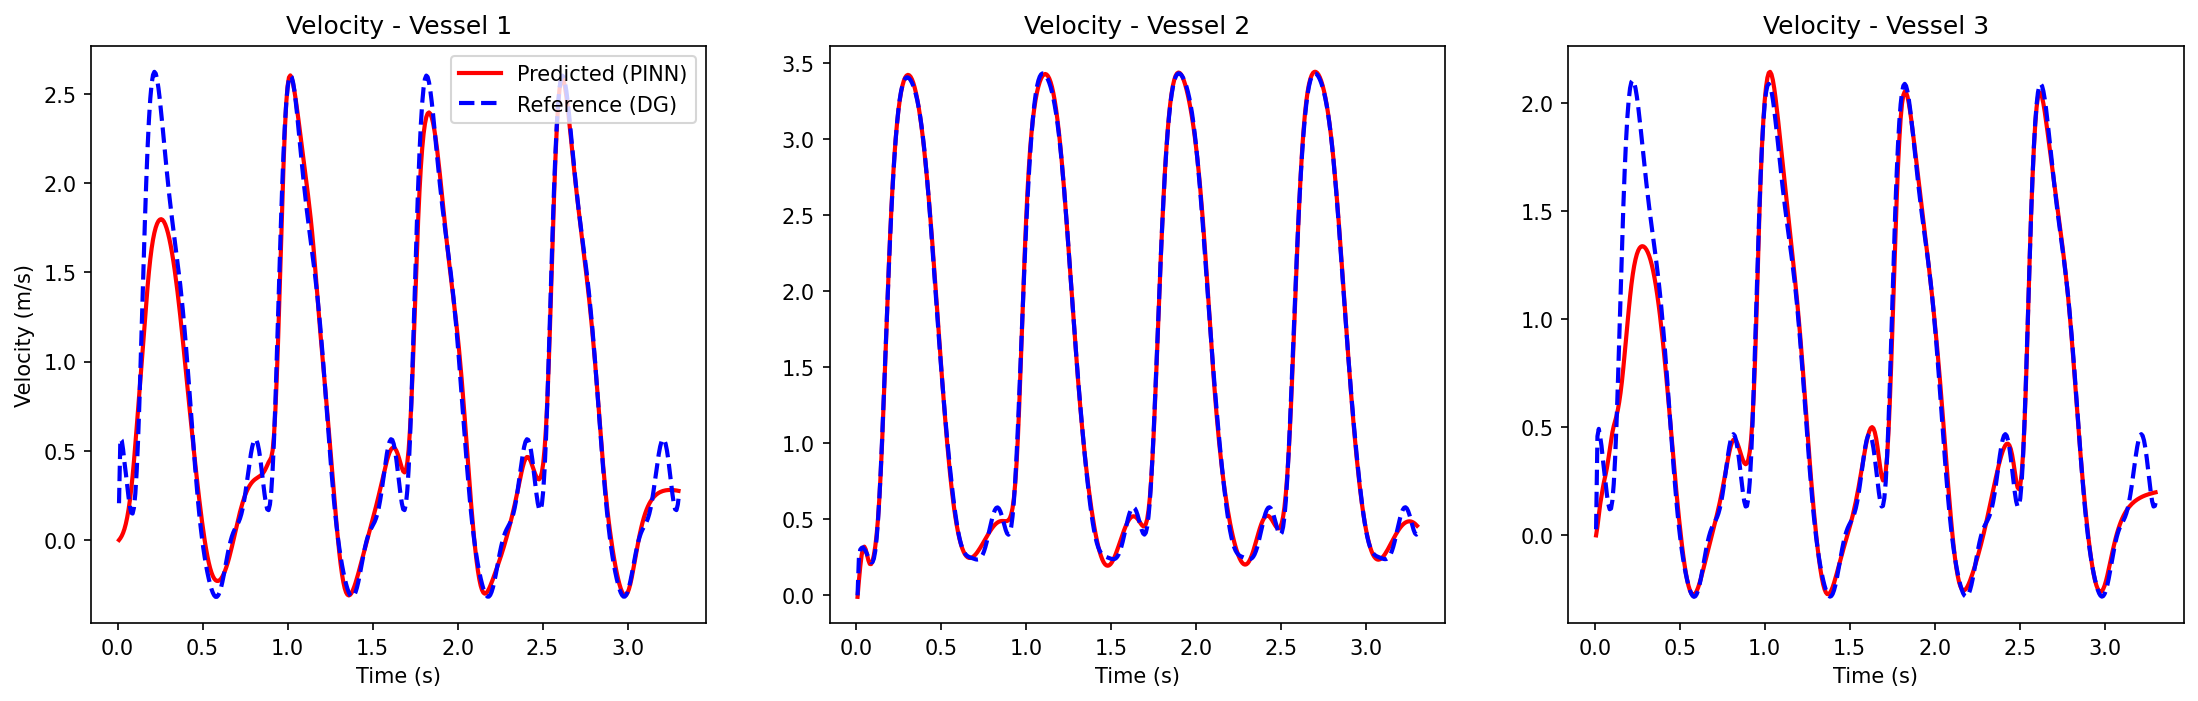

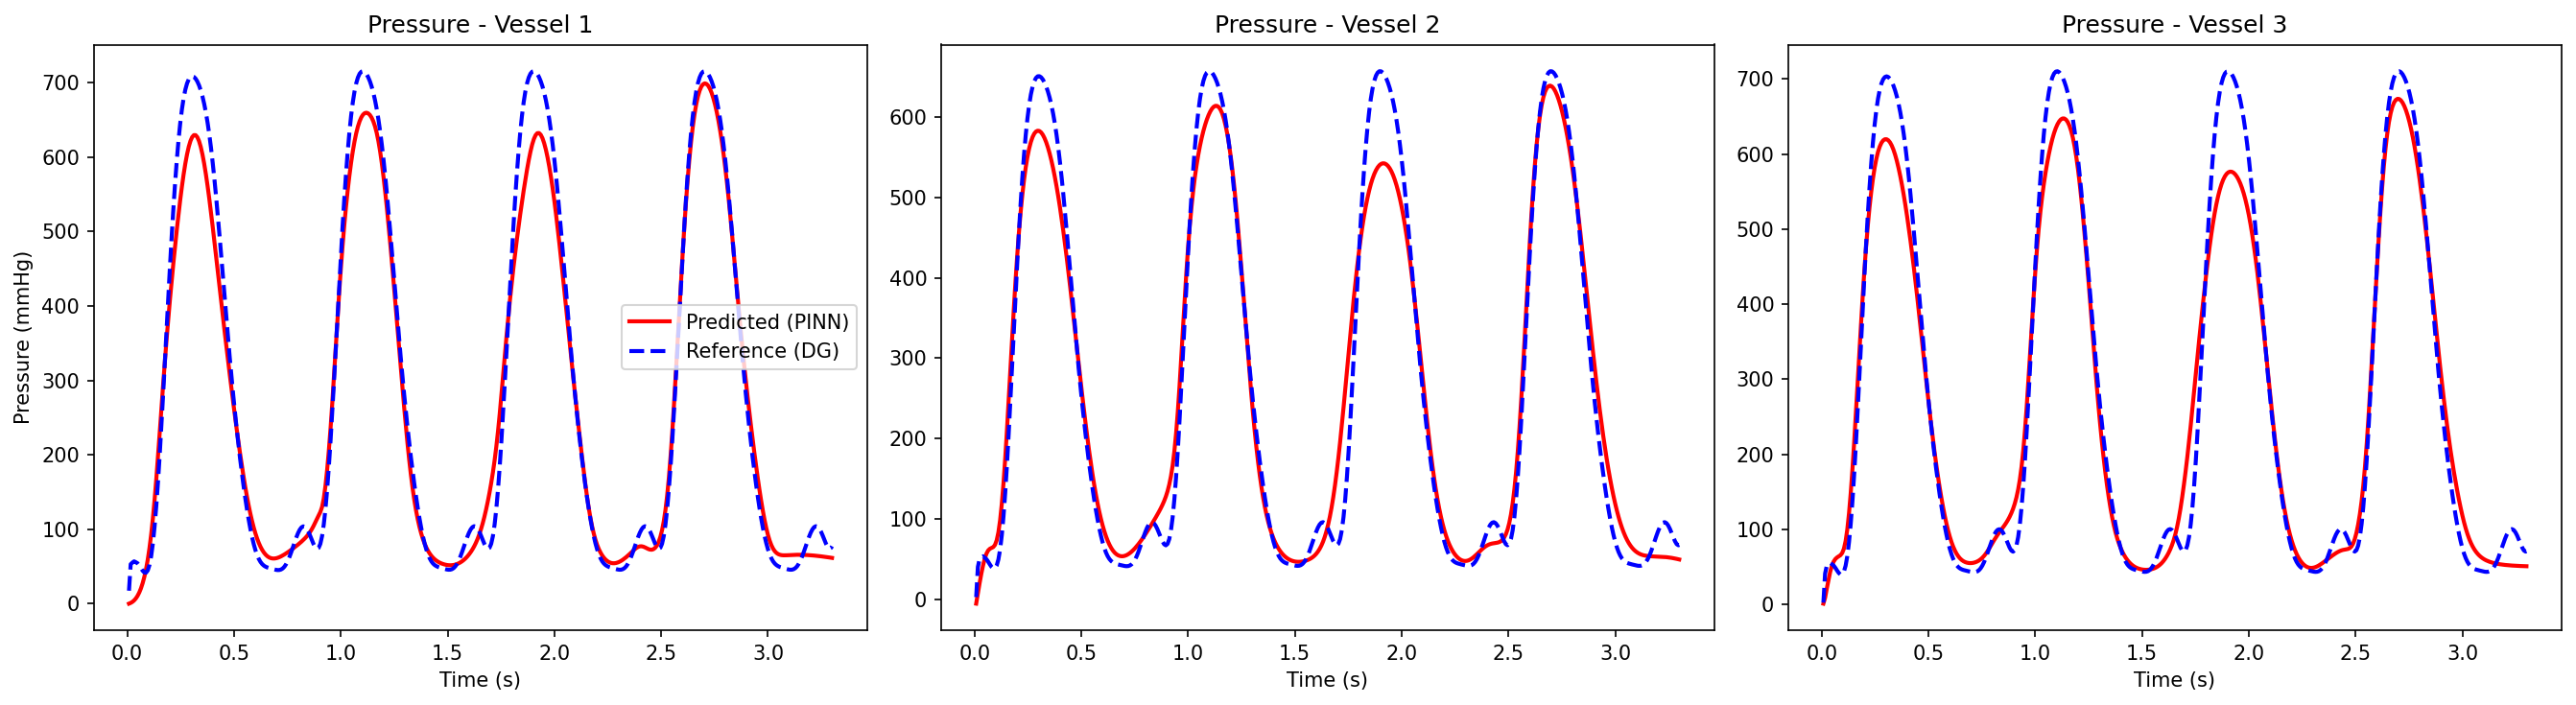

In [ ]:
if __name__ == "__main__":
    N_f =  2000

    input_vessel_1 = np.load("input_1.npy", allow_pickle=True).item()
    output_vessel_2 = np.load("output_2.npy", allow_pickle=True).item()
    output_vessel_3 = np.load("output_3.npy", allow_pickle=True).item()

    t = input_vessel_1["Time"][:,None]

    test_vessel_1 = np.load("test_1.npy", allow_pickle=True).item()
    test_vessel_2 = np.load("test_2.npy", allow_pickle=True).item()
    test_vessel_3 = np.load("test_3.npy", allow_pickle=True).item()

    velocity_measurements_vessel1 = input_vessel_1["Velocity"][:,None]
    velocity_measurements_vessel2 = output_vessel_2["Velocity"][:,None]
    velocity_measurements_vessel3 = output_vessel_3["Velocity"][:,None]

    area_measurements_vessel1 = input_vessel_1["Area"][:,None]
    area_measurements_vessel2 = output_vessel_2["Area"][:,None]
    area_measurements_vessel3 = output_vessel_3["Area"][:,None]

    velocity_test_vessel1 = test_vessel_1["Velocity"][:,None]
    velocity_test_vessel2 = test_vessel_2["Velocity"][:,None]
    velocity_test_vessel3 = test_vessel_3["Velocity"][:,None]

    pressure_test_vessel1 = test_vessel_1["Pressure"][:,None]
    pressure_test_vessel2 = test_vessel_2["Pressure"][:,None]
    pressure_test_vessel3 = test_vessel_3["Pressure"][:,None]

    N_u = t.shape[0]

    layers = [2, 100, 100, 100, 100, 100, 100, 100, 3]

    lower_bound_t = t.min(0)
    upper_bound_t = t.max(0)

    lower_bound_vessel_1 = 0.0
    upper_bound_vessel_1 = 0.1703

    lower_bound_vessel_2 = 0.1703
    upper_bound_vessel_2 = 0.1773

    lower_bound_vessel_3 = 0.1703
    upper_bound_vessel_3 = 0.1770

    bif_points = 0.1703

    X_initial_vessel1 = np.linspace(lower_bound_vessel_1,upper_bound_vessel_1,N_u)[:,None]
    X_initial_vessel2 = np.linspace(lower_bound_vessel_2,upper_bound_vessel_2,N_u)[:,None]
    X_initial_vessel3 = np.linspace(lower_bound_vessel_3,upper_bound_vessel_3,N_u)[:,None]

    T_initial  = lower_bound_t*np.ones((N_u))[:,None]

    X_boundary_vessel1 = lower_bound_vessel_1*np.ones((N_u))[:,None]
    X_boundary_vessel2 = upper_bound_vessel_2*np.ones((N_u))[:,None]
    X_boundary_vessel3 = upper_bound_vessel_3*np.ones((N_u))[:,None]

    T_boundary = t

    X_measurement_vessel1 = np.vstack((X_initial_vessel1, X_boundary_vessel1))
    X_measurement_vessel2 = np.vstack((X_initial_vessel2, X_boundary_vessel2))
    X_measurement_vessel3 = np.vstack((X_initial_vessel3, X_boundary_vessel3))

    T_measurement = np.vstack((T_initial, T_boundary))

    X_residual_vessel1 = lower_bound_vessel_1 + (upper_bound_vessel_1-lower_bound_vessel_1)*np.random.random((N_f))[:,None]
    X_residual_vessel2 = lower_bound_vessel_2 + (upper_bound_vessel_2-lower_bound_vessel_2)*np.random.random((N_f))[:,None]
    X_residual_vessel3 = lower_bound_vessel_3 + (upper_bound_vessel_3-lower_bound_vessel_3)*np.random.random((N_f))[:,None]

    T_residual = lower_bound_t + (upper_bound_t-lower_bound_t)*np.random.random((N_f))[:,None]

    A_initial_vessel1 = 1.35676200E-05*np.ones((N_u,1))
    A_initial_vessel2 = 1.81458400E-06*np.ones((N_u,1))
    A_initial_vessel3 = 1.35676200E-05*np.ones((N_u,1))

    U_initial_vessel1 = 0.*np.ones((N_u,1))
    U_initial_vessel2 = 0.*np.ones((N_u,1))
    U_initial_vessel3 = 0.*np.ones((N_u,1))

    A_training_vessel1 = np.vstack((A_initial_vessel1,area_measurements_vessel1))
    U_training_vessel1 = np.vstack((U_initial_vessel1,velocity_measurements_vessel1))

    A_training_vessel2 = np.vstack((A_initial_vessel2,area_measurements_vessel2))
    U_training_vessel2 = np.vstack((U_initial_vessel2,velocity_measurements_vessel2))

    A_training_vessel3 = np.vstack((A_initial_vessel3,area_measurements_vessel3))
    U_training_vessel3 = np.vstack((U_initial_vessel3,velocity_measurements_vessel3))

    model = OneDBioPINN(X_measurement_vessel1,
                               X_measurement_vessel2,
                               X_measurement_vessel3,
                               A_training_vessel1,  U_training_vessel1,
                               A_training_vessel2,  U_training_vessel2,
                               A_training_vessel3,  U_training_vessel3,
                               X_residual_vessel1,
                               X_residual_vessel2,
                               X_residual_vessel3,
                               T_residual, T_measurement, layers, bif_points)
    model.train(90000,1e-3)
    model.train(40000,1e-4)

    X_test_vessel1 = 0.1 * np.ones((t.shape[0], 1))
    X_test_vessel2 = 0.176 * np.ones((t.shape[0], 1))
    X_test_vessel3 = 0.174 * np.ones((t.shape[0], 1))

    # 2. HACER PREDICCIONES USANDO 't' (ORDENADO) EN LUGAR DE 'T_residual' (ALEATORIO)
    A_pred_vessel1, U_pred_vessel1, p_pred_vessel1 = model.predict_vessel1(X_test_vessel1, t)
    A_pred_vessel2, U_pred_vessel2, p_pred_vessel2 = model.predict_vessel2(X_test_vessel2, t)
    A_pred_vessel3, U_pred_vessel3, p_pred_vessel3 = model.predict_vessel3(X_test_vessel3, t)

    # 3. Factor de conversión para la Presión (De Pascals a mmHg)
    factor_p = 133.322

    # Empezamos a graficar
    fig1 = plt.figure(1, figsize=(18, 5), dpi=150, facecolor='w')
    fig2 = plt.figure(2, figsize=(18, 5), dpi=150, facecolor='w')

    ax11 = fig1.add_subplot(131); ax12 = fig1.add_subplot(132); ax13 = fig1.add_subplot(133)
    ax21 = fig2.add_subplot(131); ax22 = fig2.add_subplot(132); ax23 = fig2.add_subplot(133)

    # --- GRAFICAR VELOCIDAD ---
    # Ahora la línea roja ('r-') será suave y seguirá la onda
    ax11.plot(t, U_pred_vessel1, 'r-', linewidth=2, label='Predicted (PINN)')
    ax11.plot(t, velocity_test_vessel1, 'b--', linewidth=2, label='Reference (DG)')
    ax11.set_title("Velocity - Vessel 1"); ax11.set_xlabel("Time (s)"); ax11.set_ylabel("Velocity (m/s)")
    ax11.legend()

    ax12.plot(t, U_pred_vessel2, 'r-', linewidth=2)
    ax12.plot(t, velocity_test_vessel2, 'b--', linewidth=2)
    ax12.set_title("Velocity - Vessel 2"); ax12.set_xlabel("Time (s)")

    ax13.plot(t, U_pred_vessel3, 'r-', linewidth=2)
    ax13.plot(t, velocity_test_vessel3, 'b--', linewidth=2)
    ax13.set_title("Velocity - Vessel 3"); ax13.set_xlabel("Time (s)")

    # --- GRAFICAR PRESIÓN ---
    # Dividimos por el factor_p para que la escala esté en el rango de < 1000 (mmHg)
    # También cambiamos los puntos locos ('bo') por una línea bonita ('b-')
    ax21.plot(t, p_pred_vessel1 / factor_p, 'r-', linewidth=2, label='Predicted (PINN)')
    ax21.plot(t, pressure_test_vessel1 / factor_p, 'b--', linewidth=2, label='Reference (DG)')
    ax21.set_title("Pressure - Vessel 1"); ax21.set_xlabel("Time (s)"); ax21.set_ylabel("Pressure (mmHg)")
    ax21.legend()

    ax22.plot(t, p_pred_vessel2 / factor_p, 'r-', linewidth=2)
    ax22.plot(t, pressure_test_vessel2 / factor_p, 'b--', linewidth=2)
    ax22.set_title("Pressure - Vessel 2"); ax22.set_xlabel("Time (s)")

    ax23.plot(t, p_pred_vessel3 / factor_p, 'r-', linewidth=2)
    ax23.plot(t, pressure_test_vessel3 / factor_p, 'b--', linewidth=2)
    ax23.set_title("Pressure - Vessel 3"); ax23.set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

    fig1.savefig("Comparative_Velocity.png")
    fig2.savefig("Comparative_Pressure.png")



## Análisis Comparativo: El Impacto Crítico de la Normalización
Este bloque de código se encarga de generar la prueba definitiva del aporte matemático más importante del artículo de Kissas et al.: **la necesidad absoluta de adimensionalizar los datos**. Aquí vamos a comparar visualmente qué pasa cuando entrenamos la IA con datos "crudos" versus datos escalados.

---

### 1. Carga de Resultados Experimentales
En lugar de entrenar desde cero, el script carga los resultados guardados (`.npy`) de experimentos previos:
* **`results_bif_unnorm`:** Resultados de la PINN entrenada con datos biológicos en sus unidades originales (sin normalizar).
* **`results_bif`:** Resultados de la PINN entrenada utilizando el proceso de adimensionalización (escalando todo a valores cercanos a 1).
* **Resultados de Referencia (`test`):** Los datos reales simulados mediante el método numérico tradicional de Galerkin Discontinuo.

---

### 2. Extracción de Variables y Conversión de Unidades
Se separan las variables de tiempo ($t$), presión ($p$) y velocidad ($u$) para un punto específico de la arteria ($x = 0.08$).
> **Observación clave:** Notarás que la presión de referencia y la del modelo normalizado se dividen por **133.33**. Esto convierte la presión de Pascales a **mmHg**. Sin embargo, la predicción del modelo no normalizado (`p_pred_un`) no se divide, ya que sus gradientes matemáticos colapsaron durante el entrenamiento y la IA devolvió valores completamente fuera de la realidad.

---

### 3. Visualización de la Falla Matemática (El "Elefante y la Hormiga")
Se construyen dos gráficos de alta resolución (300 dpi) que grafican tres líneas:
* **Línea Roja continua:** La verdad absoluta o referencia (Galerkin Discontinuo).
* **Línea Azul punteada:** Nuestra IA con datos normalizados (PINN Normalizada). Debería seguir perfectamente a la línea roja.
* **Línea Negra continua:** La IA confundida por la diferencia de escalas (PINN No Normalizada). Al graficar esto con límites fijos (`set_ylim`), verás cómo esta línea se comporta de forma errática o plana, demostrando el fenómeno de "desvanecimiento de gradientes" por mezclar valores gigantes de presión con valores minúsculos de área.

---

### 4. Exportación con Calidad de Publicación
Finalmente, las gráficas no solo se muestran en pantalla, sino que se guardan usando el formato `.eps` (Encapsulated PostScript). A diferencia de un PNG o JPG, este es un formato de imagen vectorial utilizado como estándar en la publicación de *papers* científicos (como en la revista del IEEE o Elsevier) porque no pierde resolución al hacer zoom.

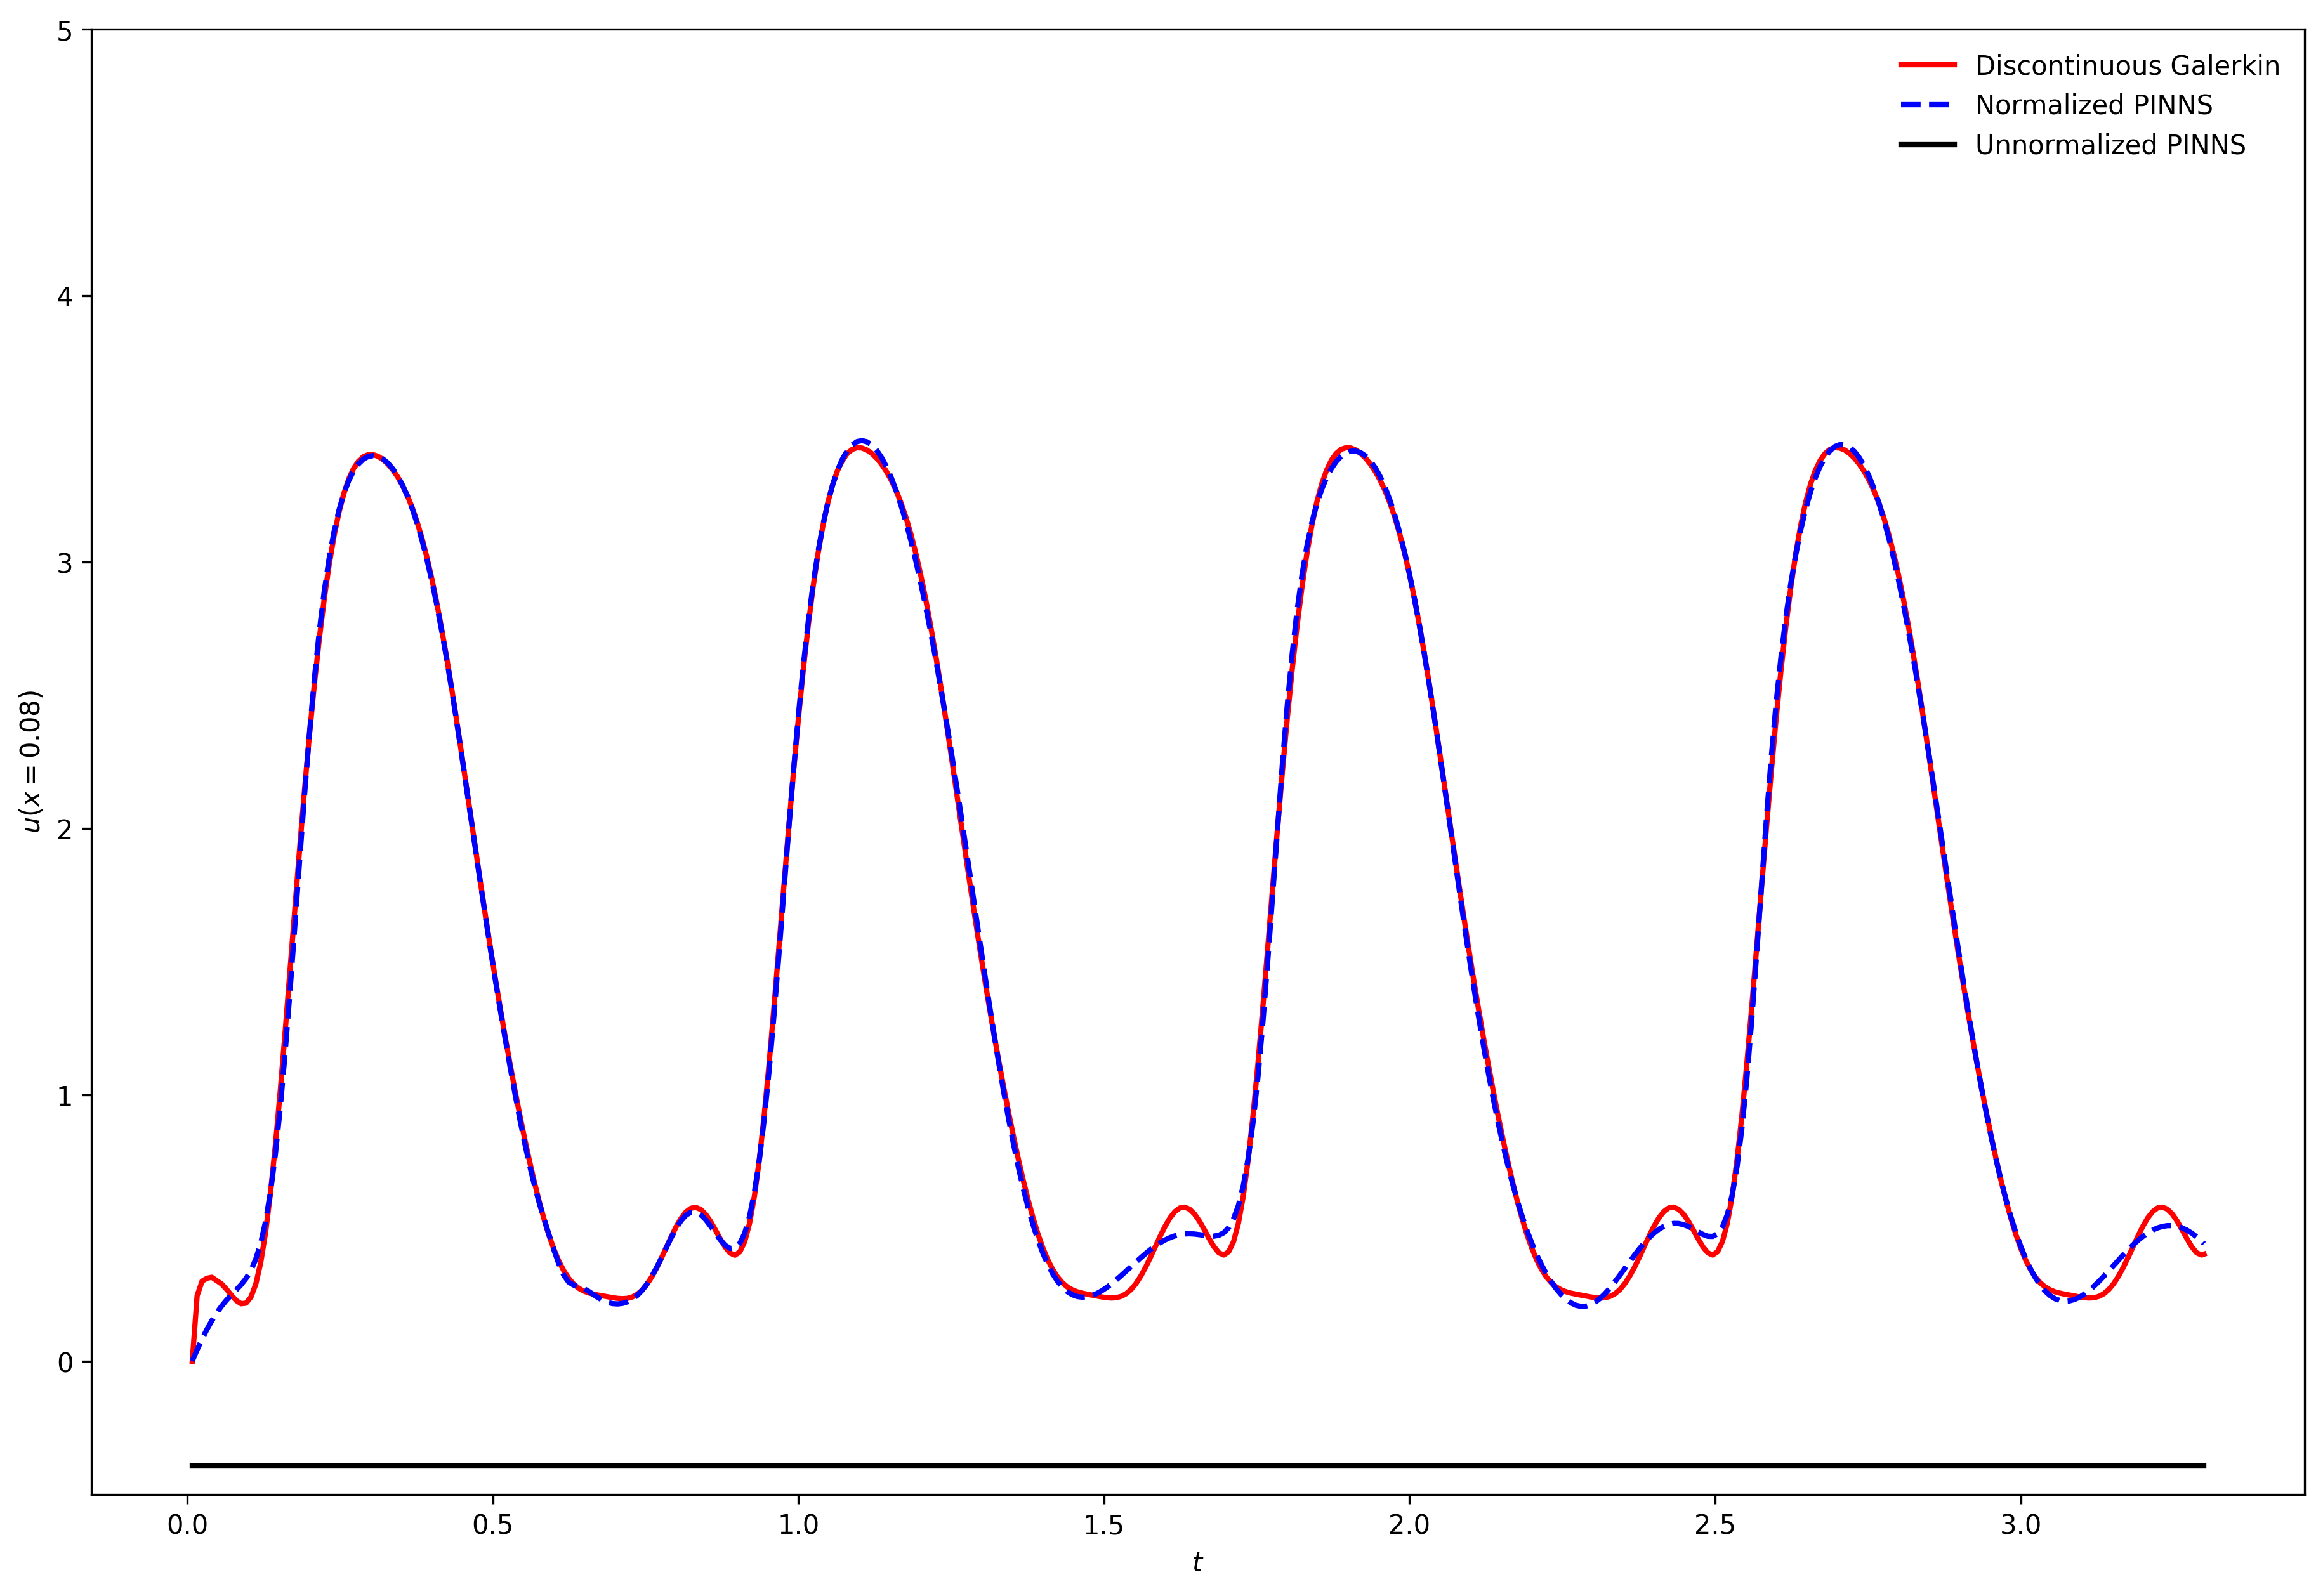

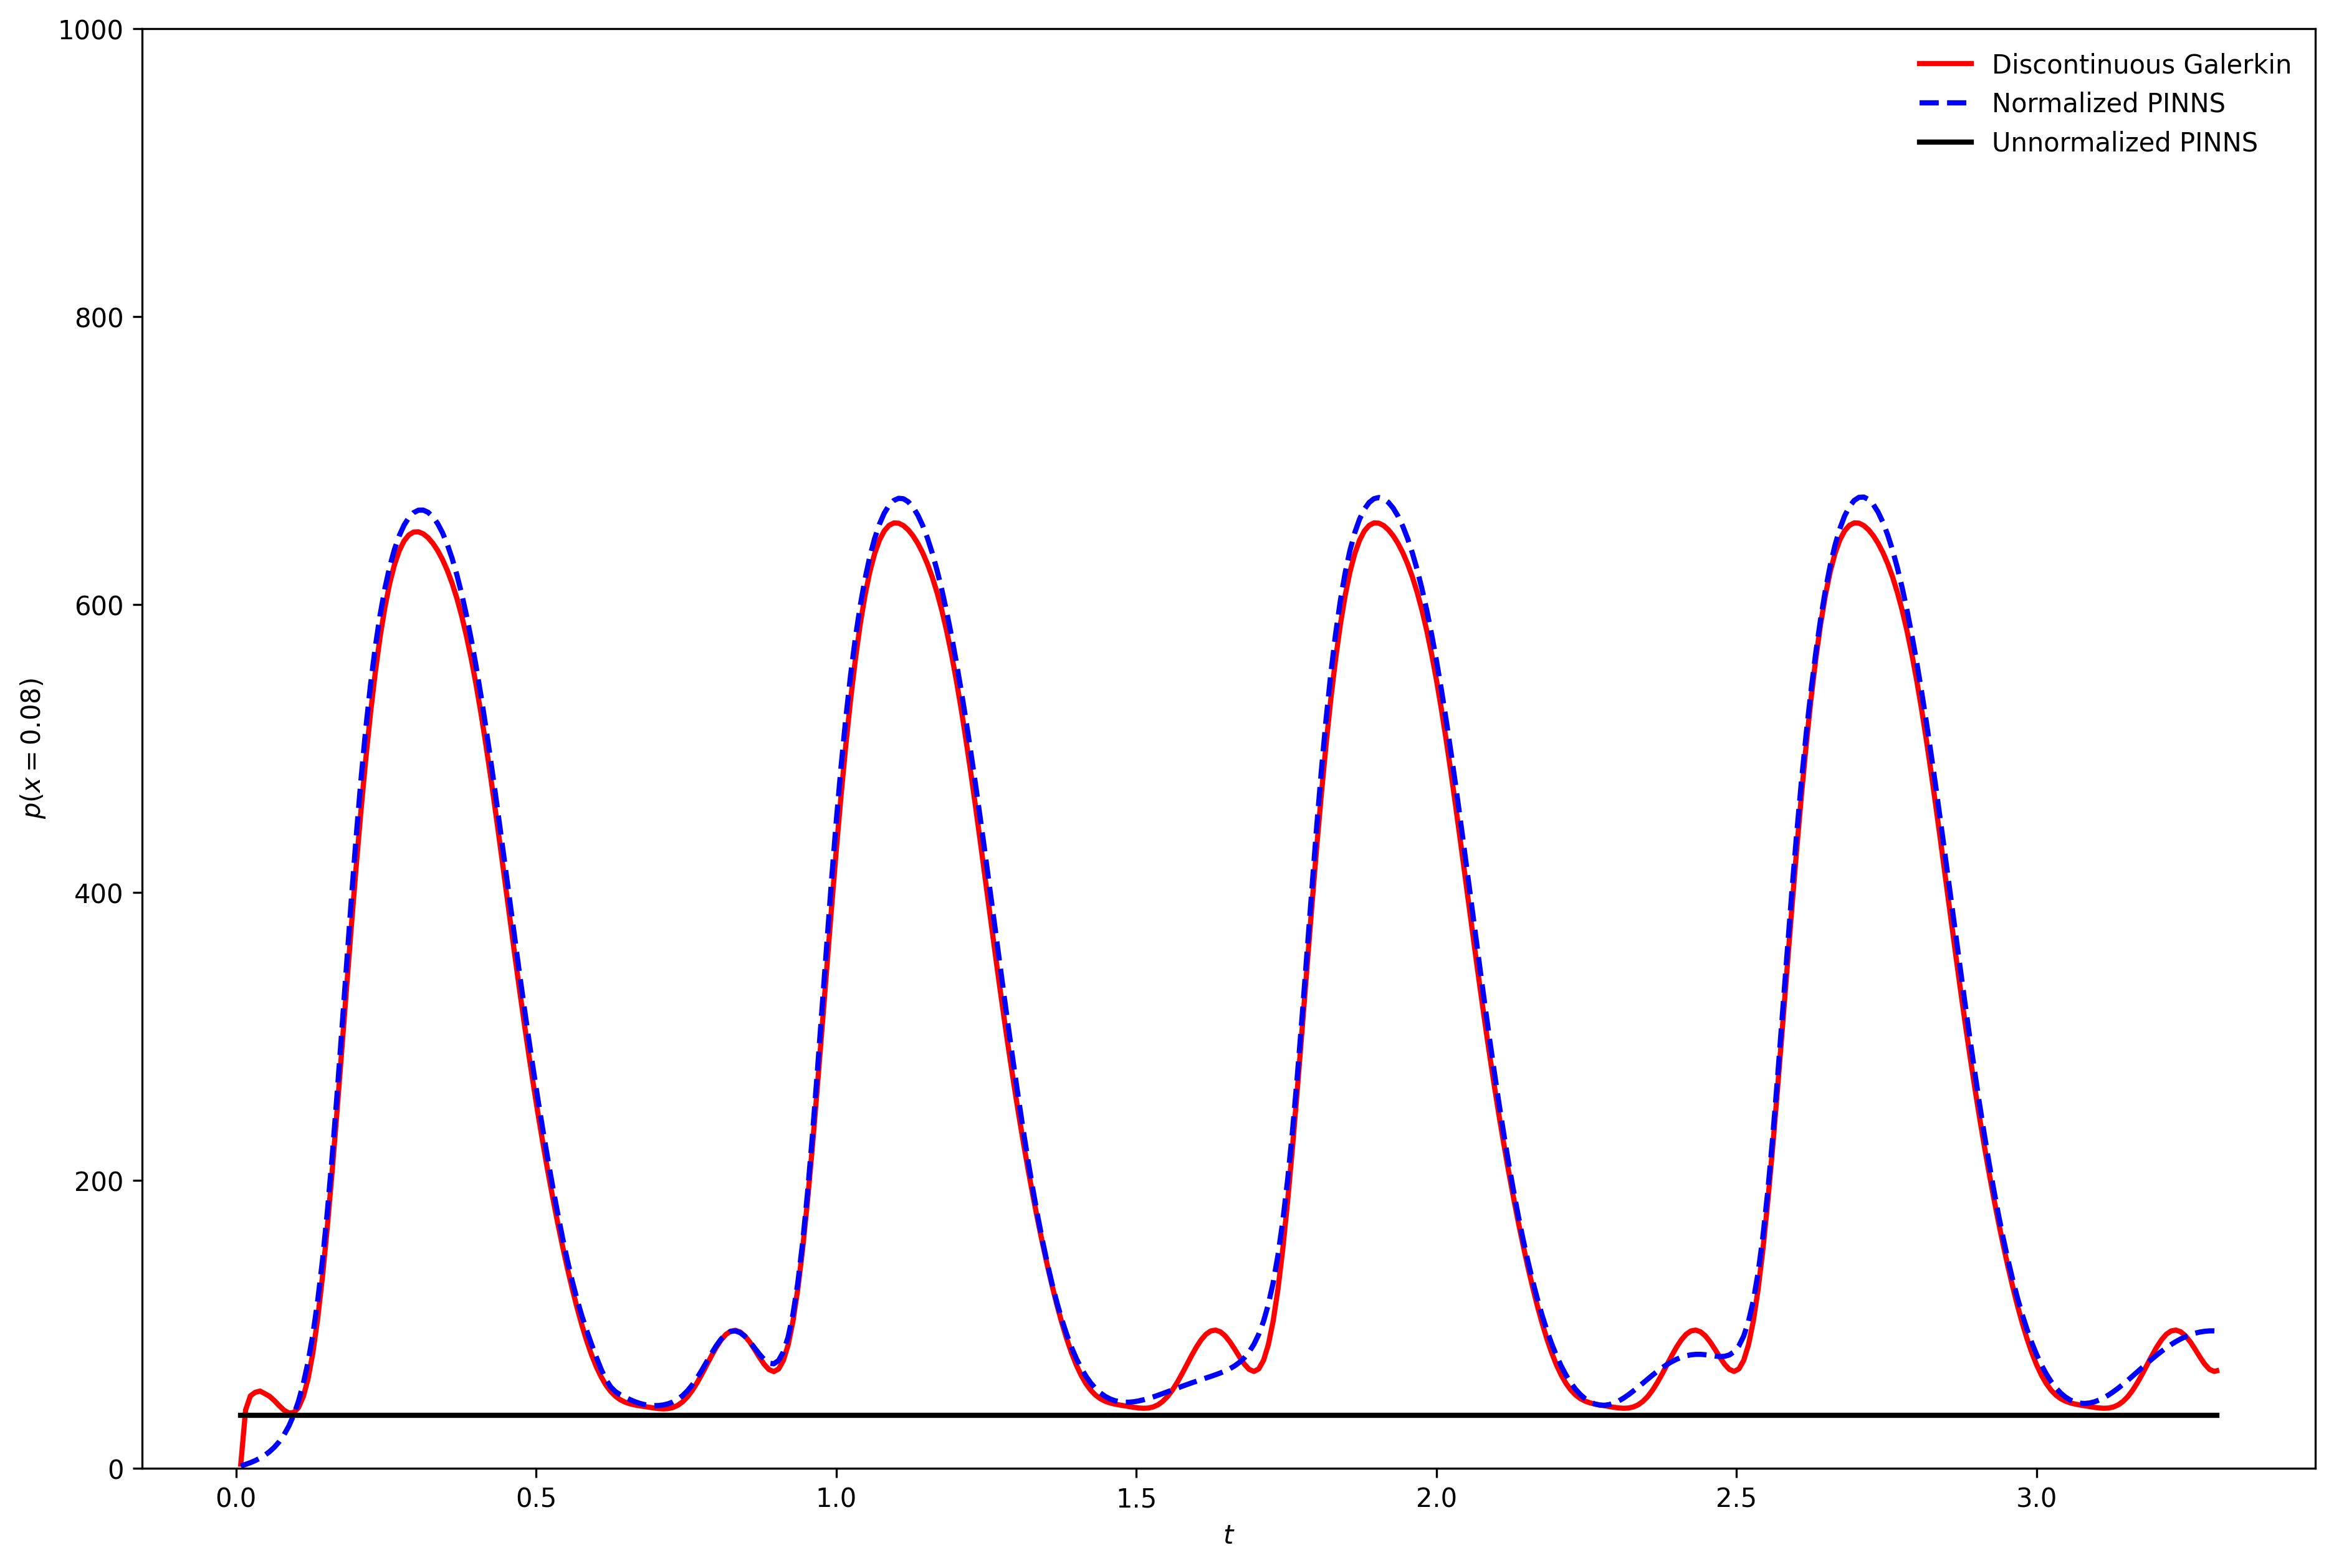

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


results_un = np.load("results_bif_unnorm.npy", allow_pickle=True).item()
results_bif = np.load("results_bif.npy", allow_pickle=True).item()
results_RCR2 = np.load("vessel_2_bif.npy", allow_pickle=True).item()
results_RCR3 = np.load("vessel_3_bif.npy", allow_pickle=True).item()

T_f = results_un["Time_f"]
t = results_un["Time_t"]
T_plot= t
p_pred_un = results_un["PredPress1"]
u_pred_un = results_un["PredVel1"]
p_pred = results_bif["PredPressl_2"]
u_pred = results_bif["PredVel_2"]
p_test = results_bif["TestPress_2"]
u_test = results_bif["TestVel_2"]
p_RCR_2 = results_RCR2["Pressure"].T
u_RCR_2 = results_RCR2["Velocity"].T
p_RCR_3 = results_RCR3["Pressure"].T
u_RCR_3 = results_RCR3["Velocity"].T

fig1 = plt.figure(1,figsize=(15, 10), dpi=300, facecolor='w', frameon = False)
fig2 = plt.figure(2,figsize=(15, 10), dpi=300, facecolor='w', frameon = False)
fig1.clf()
fig2.clf()

ax1 = fig1.add_subplot(111)
ax2 = fig2.add_subplot(111)

ax1.plot(t, u_test,'r-',linewidth=2, markersize=0.5, label = 'Discontinuous Galerkin')
ax1.plot(T_plot, u_pred,'b--',linewidth=2, markersize=0.5, label = 'Normalized PINNS')
ax1.plot(t, u_pred_un,'k-',linewidth=2, markersize=0.5, label = 'Unnormalized PINNS')
ax1.set_xlabel('$t$',fontsize=10)
ax1.set_ylabel('$u(x = 0.08)$',fontsize=10)

ax2.plot(t, p_test/133.33,'r-',linewidth=2, markersize=0.5, label = 'Discontinuous Galerkin')
ax2.plot(T_plot, p_pred/133.33,'b--',linewidth=2, markersize=0.5, label = 'Normalized PINNS')
ax2.plot(t, p_pred_un,'k-',linewidth=2, markersize=0.5, label = 'Unnormalized PINNS')
ax2.set_xlabel('$t$',fontsize=10)
ax2.set_ylabel('$p(x = 0.08)$',fontsize=10)
ax1.legend(loc='upper right', frameon=False, prop={'size': 10})
ax2.legend(loc='upper right', frameon=False, prop={'size': 10})

ax1.set_ylim(-0.5,5)
ax2.set_ylim(0,1000)


filename1 = "comparative_velocity_all.eps"
filename2 = "comparative_pressure_all.eps"

fig1.savefig(filename1, format = 'eps')
fig2.savefig(filename2, format = 'eps')

plt.show()

## Redes Arteriales Complejas: El Arco Aórtico y la Carótida
En este bloque, llevamos la Inteligencia Artificial al siguiente nivel escalando el problema. Pasamos de un modelo básico a una red de 4 vasos sanguíneos que simula el flujo en la Aorta y la Arteria Carótida Común izquierda.

---

### 1. Carga de Datos y Escalado de Unidades
El código comienza importando los datos de velocidad y área para los cuatro vasos. Hay un detalle técnico sumamente importante aquí:
* **Escalado manual:** Los datos originales vienen en unidades mixtas. El código los multiplica por factores de conversión (`1e-3`, `1e-2`, `1e-6`) para estandarizarlos rigurosamente al Sistema Internacional (segundos, metros por segundo y metros cuadrados, respectivamente). Esto ayuda a la estabilidad matemática de la red.
* **Dominio espacial:** Se definen los límites físicos (`lower_bound` y `upper_bound`) creando una topología conectada de 4 segmentos arteriales, con sus respectivos puntos de bifurcación.

---

### 2. Transfer Learning (Aprendizaje Transferido)
Aquí se encuentra uno de los mayores "trucos" para ahorrar tiempo de cómputo en la IA:
* En lugar de entrenar los pesos de la red neuronal desde cero (lo cual podría tomar cientos de miles de iteraciones y varias horas), el modelo carga un "cerebro" que ya estudió física antes (`model.saver.restore(...)`), usando un archivo de punto de control (`.ckpt`).
* Luego, simplemente se hace un **ajuste fino (*fine-tuning*)** de apenas 200 iteraciones con "mini-batches" para adaptar este cerebro pre-entrenado a las condiciones exactas de este paciente o simulación en particular.

---

### 3. Predicción e Inferencia en Fronteras
Se extraen las predicciones del modelo en las fronteras físicas del sistema:
* La entrada principal (Aorta 1).
* Las salidas (Aorta 4 y la Carótida).
* Un nodo interno de prueba (Aorta 3).

---

### 4. Panel de Verificación Visual (2x2)
Para evaluar la precisión del modelo de un solo vistazo, se construye una figura compuesta por 4 subgráficas:
* **Línea Azul continua:** Las mediciones reales o datos de referencia del paciente/simulación.
* **Línea Roja punteada:** La predicción de nuestra red PINN.
* La superposición de ambas curvas demuestra que la red neuronal informada por la física es capaz de capturar la dinámica compleja de la sangre a través del tiempo en múltiples vasos simultáneamente.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(1234)
tf.set_random_seed(1234)

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
N_f =  2000

aorta1_velocity = np.load("/content/data/Aorta1_U.npy", allow_pickle=True).item()
aorta2_velocity = np.load("/content/data/Aorta2_U.npy", allow_pickle=True).item()
aorta4_velocity = np.load("/content/data/Aorta4_U.npy", allow_pickle=True).item()
carotid_velocity= np.load("/content/data/LCommonCarotid_U.npy", allow_pickle=True).item()

aorta1_area = np.load("/content/data/Aorta1_A.npy", allow_pickle=True).item()
aorta2_area = np.load("/content/data/Aorta2_A.npy", allow_pickle=True).item()
aorta4_area = np.load("/content/data/Aorta4_A.npy", allow_pickle=True).item()
carotid_area = np.load("/content/data/LCommonCarotid_A.npy", allow_pickle=True).item()

test_aorta3_velocity = np.load("/content/data/Aorta3_U.npy", allow_pickle=True).item()
test_aorta3_area = np.load("/content/data/Aorta3_A.npy", allow_pickle=True).item()

t = aorta1_velocity['t']*1e-3

velocity_measurements_aorta1 = aorta1_velocity["U"]*1e-2
velocity_measurements_carotid = carotid_velocity["U"]*1e-2
velocity_measurements_aorta4 = aorta4_velocity["U"]*1e-2

area_measurements_aorta1 = aorta1_area["A"]*1e-6
area_measurements_carotid = carotid_area["A"]*1e-6
area_measurements_aorta4 = aorta4_area["A"]*1e-6

velocity_testpoint_aorta3 = test_aorta3_velocity["U"]*1e-2
area_testpoint_aorta3 = test_aorta3_area["A"]*1e-6

u_test1 = aorta2_velocity['U']*1e-2
A_test1 = aorta2_area['A']*1e-6

# Number of measurements

N_u = t.shape[0]

layers = [2, 100, 100, 100, 100, 100, 100, 3]

lower_bound_t = t.min(0)
upper_bound_t = t.max(0)

lower_bound_vessel_1 = 0.0
upper_bound_vessel_1 = 0.04964

lower_bound_vessel_2 = 0.04964
upper_bound_vessel_2 = 0.10284

lower_bound_vessel_3 = 0.04964
upper_bound_vessel_3 = 0.1383

lower_bound_vessel_4 = 0.1383
upper_bound_vessel_4 = 0.17056

# Spatial/temporal coordinates for initial conditions
X_initial_aorta1 = np.linspace(lower_bound_vessel_1,upper_bound_vessel_1,N_u)[:,None]
X_initial_carotid = np.linspace(lower_bound_vessel_2,upper_bound_vessel_2,N_u)[:,None]
X_initial_aorta3 = np.linspace(lower_bound_vessel_3,upper_bound_vessel_3,N_u)[:,None]
X_initial_aorta4 = np.linspace(lower_bound_vessel_4,upper_bound_vessel_4,N_u)[:,None]

T_initial  = lower_bound_t*np.ones((N_u))[:,None]

# Spatial/temporal coordinates for boundary conditions
X_boundary_aorta1 = lower_bound_vessel_1*np.ones((N_u))[:,None]
X_boundary_carotid = upper_bound_vessel_2*np.ones((N_u))[:,None]
X_boundary_aorta3 = upper_bound_vessel_3*np.ones((N_u))[:,None]
X_boundary_aorta4 = upper_bound_vessel_4*np.ones((N_u))[:,None]

T_boundary = t

# Measurement Spatial/temporal coordinates
X_measurement_aorta1 = np.vstack((X_initial_aorta1, X_boundary_aorta1))
X_measurement_carotid = np.vstack((X_initial_carotid, X_boundary_carotid))
X_measurement_aorta3 = np.vstack((X_initial_aorta3))
X_measurement_aorta4 = np.vstack((X_initial_aorta4, X_boundary_aorta4))

T_measurement = np.vstack((T_initial, T_boundary))

X_residual_aorta1 = lower_bound_vessel_1 + (upper_bound_vessel_1-lower_bound_vessel_1)*np.random.random((N_f))[:,None]
X_residual_carotid = lower_bound_vessel_2 + (upper_bound_vessel_2-lower_bound_vessel_2)*np.random.random((N_f))[:,None]
X_residual_aorta3 = lower_bound_vessel_3 + (upper_bound_vessel_3-lower_bound_vessel_3)*np.random.random((N_f))[:,None]
X_residual_aorta4 = lower_bound_vessel_4 + (upper_bound_vessel_4-lower_bound_vessel_4)*np.random.random((N_f))[:,None]

T_residual = lower_bound_t + (upper_bound_t-lower_bound_t)*np.random.random((N_f))[:,None]

A_initial_aorta1 = get_equilibrium_cross_sectional_area_aorta_1(X_initial_aorta1)
A_initial_carotid = get_equilibrium_cross_sectional_area_carotid(X_initial_carotid)
A_initial_aorta3 = get_equilibrium_cross_sectional_area_aorta_3(X_initial_aorta3)
A_initial_aorta4 = get_equilibrium_cross_sectional_area_aorta_4(X_initial_aorta4)

U_initial_aorta1 = velocity_measurements_aorta1[0]*np.ones((N_u,1))
U_initial_aorta2 = velocity_measurements_carotid[0]*np.ones((N_u,1))
U_initial_aorta3 = velocity_testpoint_aorta3[0]*np.ones((N_u,1))
U_initial_aorta4 = velocity_measurements_aorta4[0]*np.ones((N_u,1))

A_training_aorta1 = np.vstack((A_initial_aorta1,area_measurements_aorta1))
U_training_aorta1 = np.vstack((U_initial_aorta1,velocity_measurements_aorta1))

A_training_carotid = np.vstack((A_initial_carotid,area_measurements_carotid))
U_training_carotid = np.vstack((U_initial_aorta2,velocity_measurements_carotid))

A_training_aorta3 = np.vstack((A_initial_aorta3))
U_training_aorta3 = np.vstack((U_initial_aorta3))

A_training_aorta4 = np.vstack((A_initial_aorta4,area_measurements_aorta4))
U_training_aorta4 = np.vstack((U_initial_aorta4,velocity_measurements_aorta4))

bif_points = [upper_bound_vessel_1, upper_bound_vessel_3]

In [ ]:
# Build the PINN model
model = OneDBioPINN(X_measurement_aorta1, X_measurement_carotid,
                    X_measurement_aorta3, X_measurement_aorta4,
                    T_measurement, T_initial,
                    A_training_aorta1,  U_training_aorta1,
                    A_training_carotid, U_training_carotid,
                    A_training_aorta3,  U_training_aorta3,
                    A_training_aorta4,  U_training_aorta4,
                    X_residual_aorta1,
                    X_residual_carotid,
                    X_residual_aorta3,
                    X_residual_aorta4,
                    T_residual,
                    layers,
                    bif_points)

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5



In [ ]:
# Load pre-trained model
model.saver.restore(model.sess, '../content/SavedModels/CarotidBifurcation.ckpt')

# Train the PINN model using mini-batch stochastic gradient descent
model.train(nIter = 200, batch_size = 1024, learning_rate = 1e-4)

100%|██████████| 200/200 [00:14<00:00, 14.24it/s]


In [ ]:
# Evaluate model predictions at the test locations
test_point1 = 0.04964*np.ones((X_residual_aorta1.shape[0],1))
test_point3 = 0.1383*np.ones((t.shape[0],1))

test_aorta1_lboundary = lower_bound_vessel_1*np.ones((t.shape[0],1))
test_carotid_rboundary = upper_bound_vessel_2*np.ones((t.shape[0],1))
test_aorta4_rboundary = upper_bound_vessel_4*np.ones((t.shape[0],1))

A_predict_aorta1, u_predict_aorta1, p_predict_aorta1     = model.predict_aorta1(test_point1, T_residual)
A_predict_carotid, u_predict_carotid, p_predict_carotid    = model.predict_carotid(test_point1, T_residual)
A_predict_aorta3l, u_predict_aorta3l, p_predict_aorta3l  = model.predict_aorta3(test_point1, T_residual)
A_predict_aorta4, u_predict_aorta4, p_predict_aorta4  = model.predict_aorta4(test_point3, t)

A_pred1b, u_pred1b, p_pred1b  = model.predict_aorta1(test_aorta1_lboundary, t)
A_pred2b, u_pred2b, p_pred2b  = model.predict_carotid(test_carotid_rboundary, t)
A_pred3b, u_pred3b, p_pred3b  = model.predict_aorta4(test_aorta4_rboundary, t)

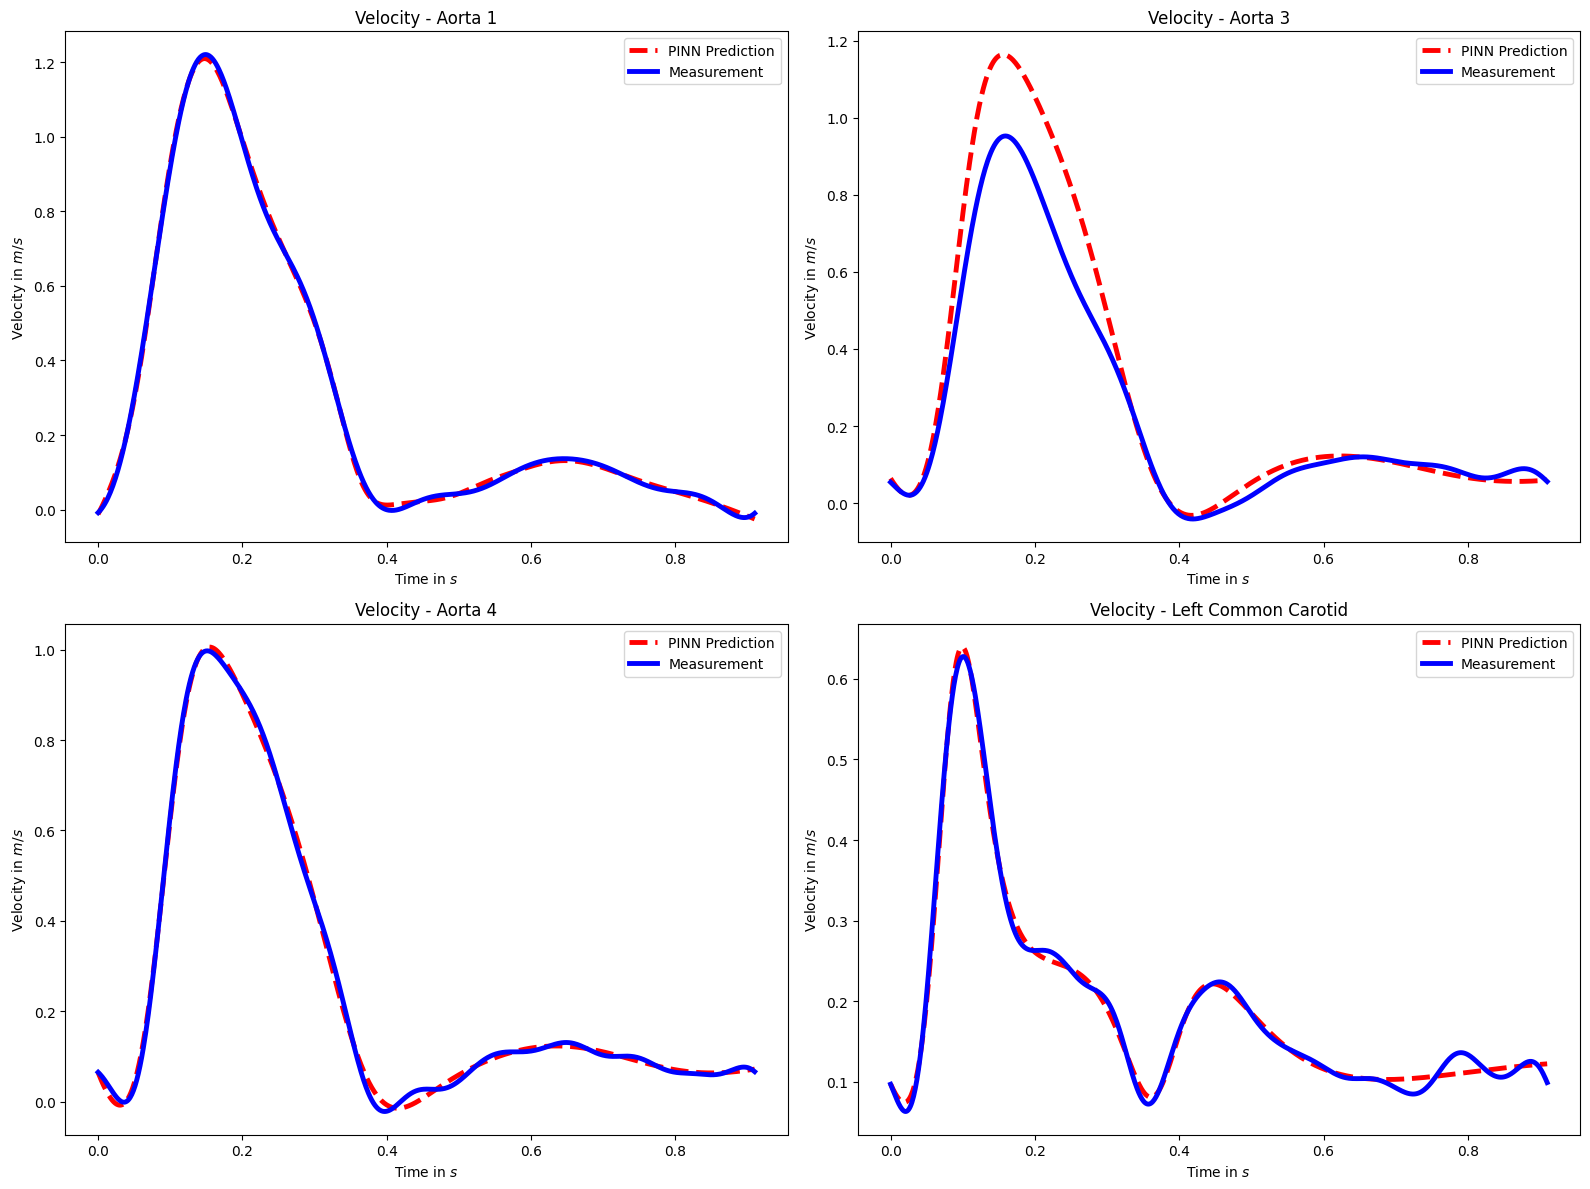

In [ ]:
import matplotlib.pyplot as plt

# Crear una figura con 4 subgráficas (2 filas y 2 columnas)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfica para Aorta 1
axs[0, 0].plot(t, u_pred1b, 'r--', linewidth=3.5, label='PINN Prediction')
axs[0, 0].plot(t, velocity_measurements_aorta1, 'b-', linewidth=3.5, label='Measurement')
axs[0, 0].set_xlabel('Time in $s$')
axs[0, 0].set_ylabel('Velocity in $m/s$')
axs[0, 0].set_title('Velocity - Aorta 1')
axs[0, 0].legend(loc='upper right')

# 2. Gráfica para Aorta 3 (Nota: se usa u_predict_aorta4 como aproximación en ese nodo)
axs[0, 1].plot(t, u_predict_aorta4, 'r--', linewidth=3.5, label='PINN Prediction')
axs[0, 1].plot(t, velocity_testpoint_aorta3, 'b-', linewidth=3.5, label='Measurement')
axs[0, 1].set_xlabel('Time in $s$')
axs[0, 1].set_ylabel('Velocity in $m/s$')
axs[0, 1].set_title('Velocity - Aorta 3')
axs[0, 1].legend(loc='upper right')

# 3. Gráfica para Aorta 4
axs[1, 0].plot(t, u_pred3b, 'r--', linewidth=3.5, label='PINN Prediction')
axs[1, 0].plot(t, velocity_measurements_aorta4, 'b-', linewidth=3.5, label='Measurement')
axs[1, 0].set_xlabel('Time in $s$')
axs[1, 0].set_ylabel('Velocity in $m/s$')
axs[1, 0].set_title('Velocity - Aorta 4')
axs[1, 0].legend(loc='upper right')

# 4. Gráfica para Left Common Carotid
axs[1, 1].plot(t, u_pred2b, 'r--', linewidth=3.5, label='PINN Prediction')
axs[1, 1].plot(t, velocity_measurements_carotid, 'b-', linewidth=3.5, label='Measurement')
axs[1, 1].set_xlabel('Time in $s$')
axs[1, 1].set_ylabel('Velocity in $m/s$')
axs[1, 1].set_title('Velocity - Left Common Carotid')
axs[1, 1].legend(loc='upper right')

# Ajustar los márgenes para que los títulos y etiquetas no se solapen
plt.tight_layout()
plt.show()

## Monitoreo del Entrenamiento: Historial de Funciones de Pérdida (*Losses*)
Este bloque de código se encarga de graficar la evolución de los diferentes componentes de la función de pérdida a lo largo de las iteraciones de entrenamiento. En las PINNs, no basta con ver que la "pérdida total" baje; necesitamos auditar por separado cada término para asegurarnos de que la IA esté equilibrando el aprendizaje de los datos con el respeto a las leyes físicas.

---

### 1. Desglose de los Componentes de Pérdida
El script carga el archivo `Losses.npy` y extrae los distintos errores que el optimizador intentó minimizar de forma simultánea:
* **Pérdida de Continuidad (`Continuity Loss`):** Evalúa el error en los puntos de bifurcación e interfaces, garantizando que la masa del fluido se conserve perfectamente al pasar de un vaso a los otros.
* **Pérdida de Reconstrucción de Área y Velocidad (`Reconstruction Loss`):** Mide qué tan fiel es la red neuronal respecto a las mediciones reales de entrada.
* **Pérdida Residual (`Residual Loss`):** Mide directamente el error en las ecuaciones diferenciales parciales (Navier-Stokes 1D). Si esta curva no baja, la red estará memorizando datos, pero violando la física de fluidos.
* **Pérdida de Presión (`Pressure Loss`):** Cuantifica la precisión en la estimación del perfil de presiones.

---

### 2. Ajuste de Escala del Historial
* **Eje X (Iteraciones):** Dado que las pérdidas no se guardan en cada paso individual para ahorrar memoria y tiempo de escritura, los datos se multiplican por un factor de 100 (`np.arange(...) * 100`) para reflejar la escala real de las iteraciones del optimizador.

---

### 3. Visualización en Escala Logarítmica
> **Nota de Diseño Matemático:** El código incluye la instrucción crucial `ax1.set_yscale('log')`.
>
> Al inicio del entrenamiento, los errores suelen ser enormes (valores de 10, 100 o más), pero al finalizar caen a valores microscópicos (como 0.001 o menos). Si graficáramos esto en una escala lineal estándar, las curvas iniciales se comerían todo el gráfico y el comportamiento final se vería como una línea plana pegada al suelo. La escala logarítmica nos permite observar con precisión caídas de múltiples órdenes de magnitud en un mismo lienzo.

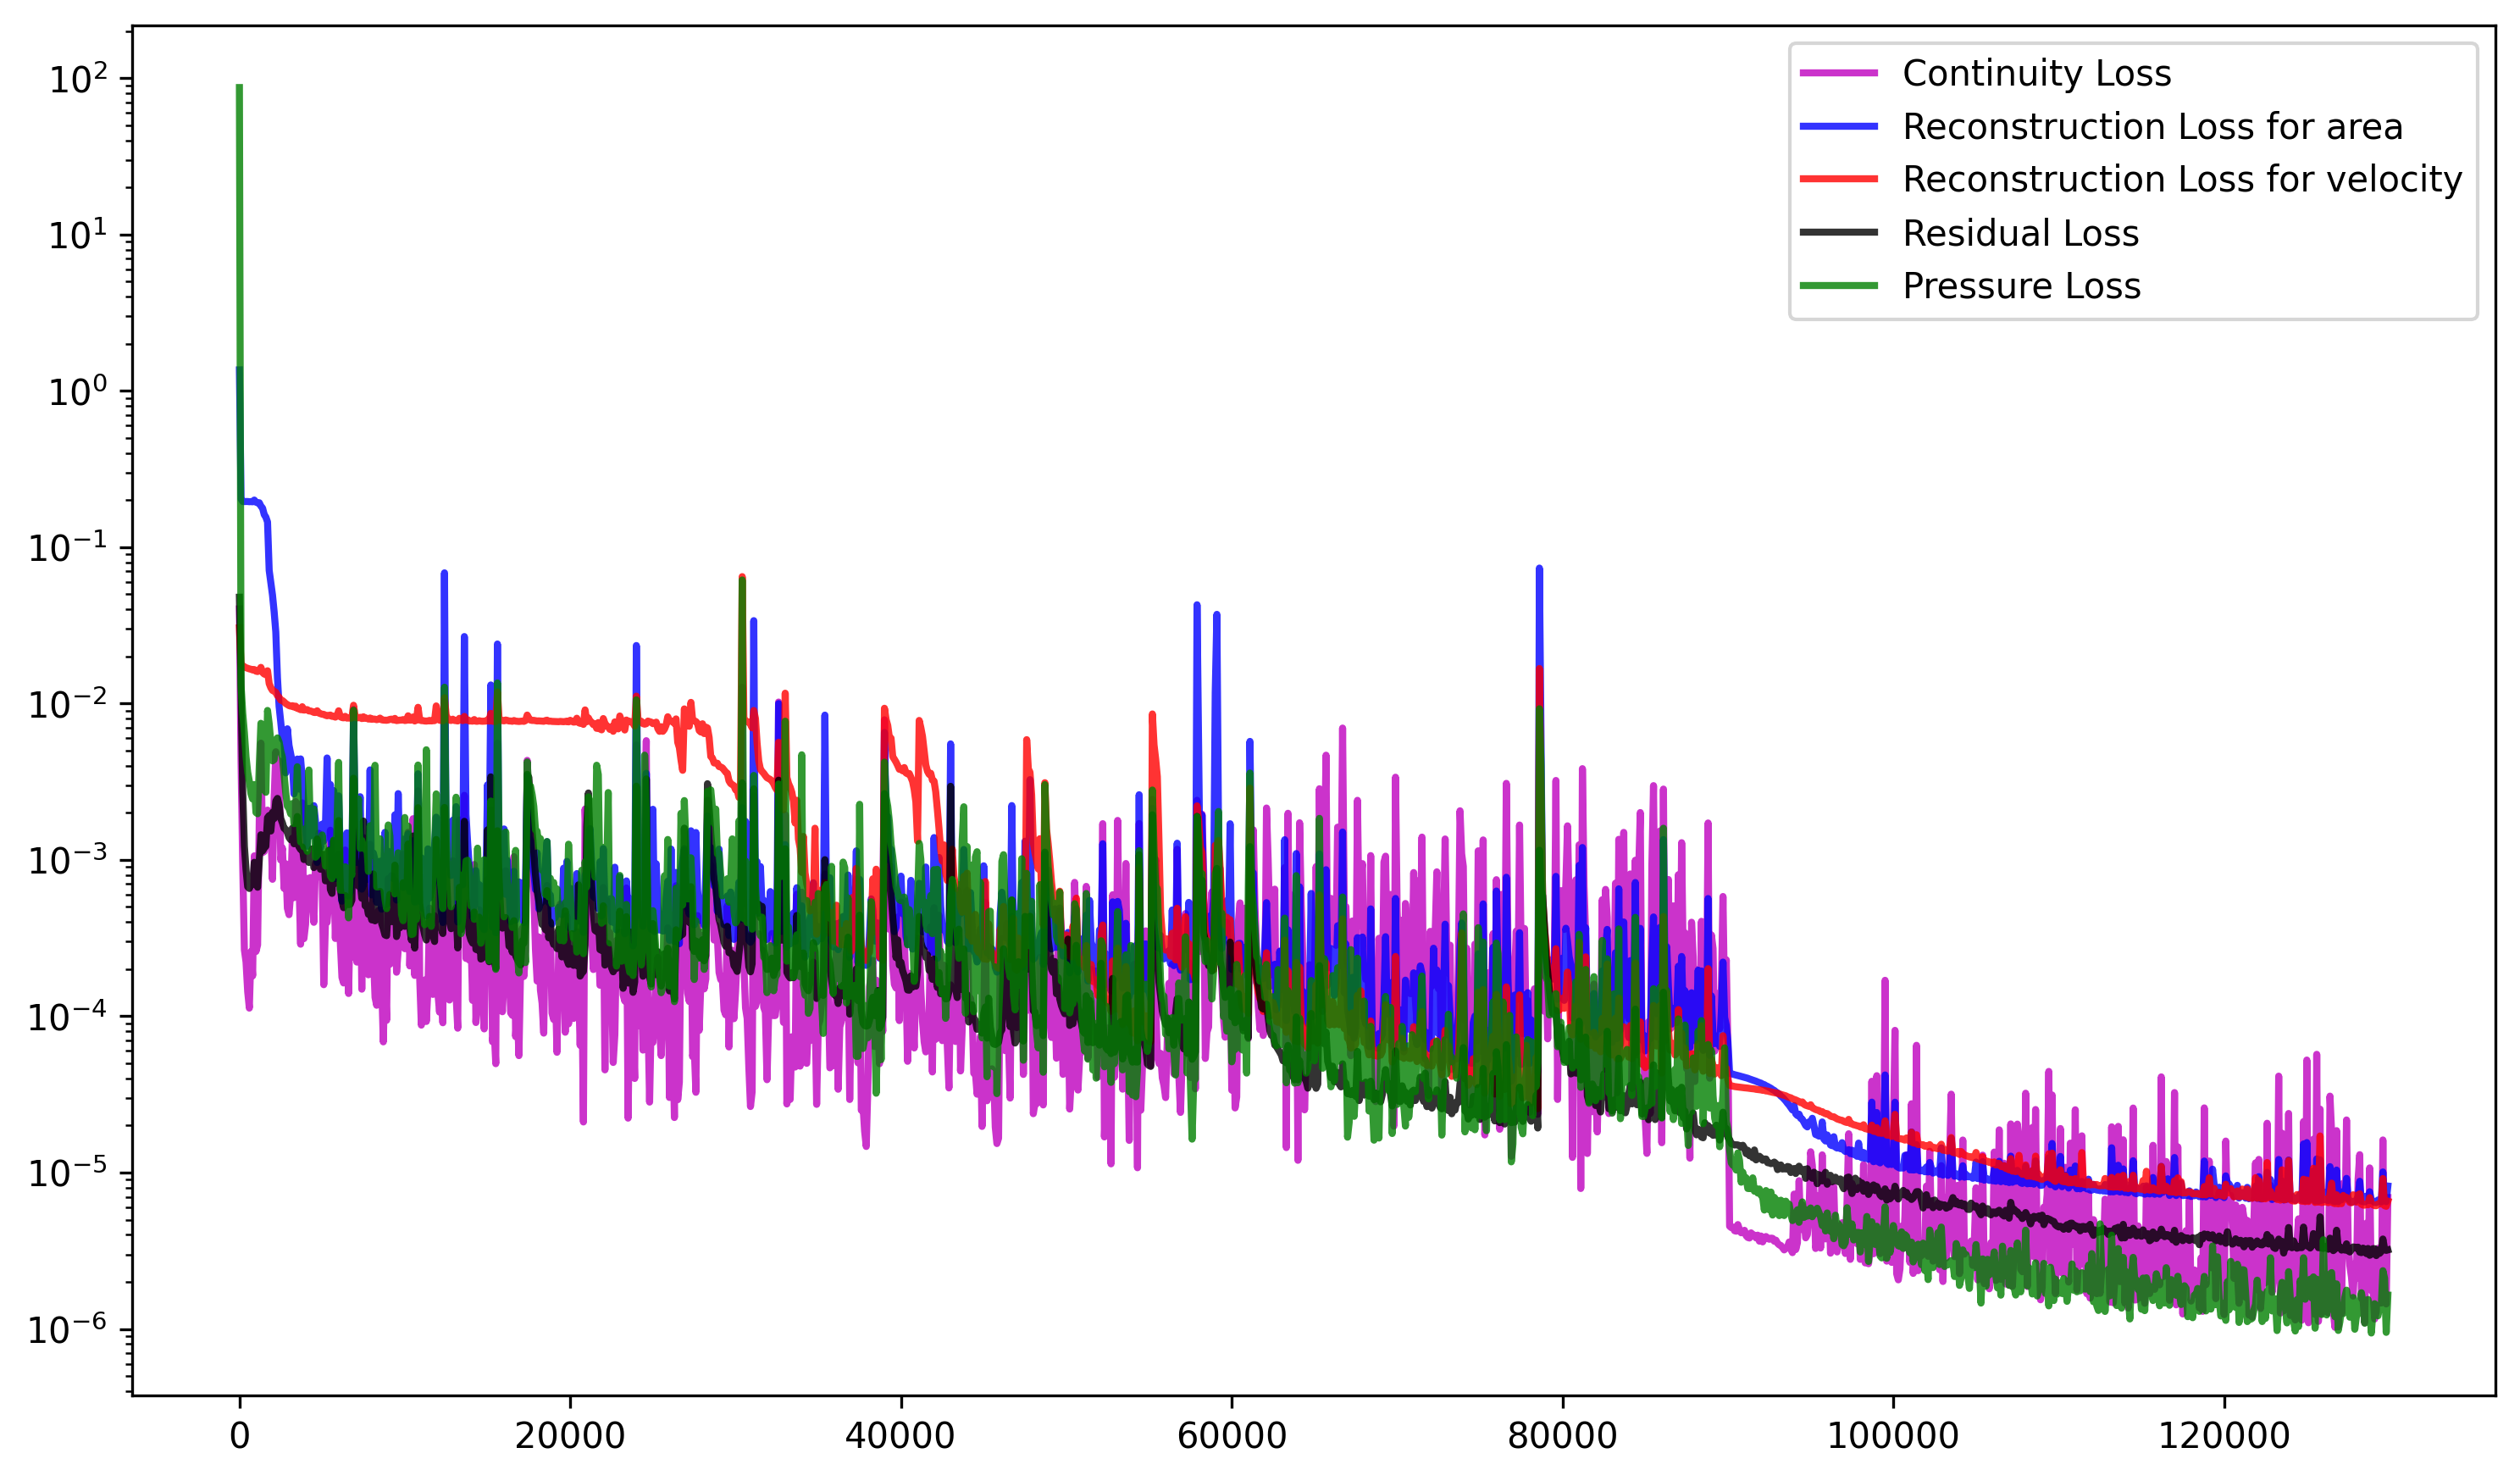

In [ ]:
results = np.load("Losses.npy", allow_pickle=True).item()

total_loss = results['Total_Loss'][:,None]
loss_area  = results['loss_area' ][:,None]
loss_velo  = results['loss_velo' ][:,None]
loss_res   = results['loss_res'  ][:,None]
loss_press = results['loss_press'][:,None]
loss_cont  = results['loss_cont' ][:,None]

iteration = np.arange(0,total_loss.shape[0])*100

fig1 = plt.figure(1,figsize=(12, 7), dpi=300, facecolor='w', frameon = False)

fig1.clf()

ax1 = fig1.add_subplot(111)

ax1.plot(iteration, loss_cont,'m-',linewidth=2, markersize=0.5, alpha = 0.8, label = 'Continuity Loss' )
ax1.plot(iteration, loss_area,'b-',linewidth=2, markersize=0.5, alpha = 0.8, label = 'Reconstruction Loss for area' )
ax1.plot(iteration, loss_velo,'r-',linewidth=2, markersize=0.5, alpha = 0.8, label = 'Reconstruction Loss for velocity' )
ax1.plot(iteration, loss_res,'k-',linewidth=2, markersize=0.5, alpha = 0.8, label = 'Residual Loss'  )
ax1.plot(iteration, loss_press,'g-',linewidth=2, markersize=0.5, alpha = 0.8, label = 'Pressure Loss' )

ax1.legend()
ax1.set_yscale('log')
filename1 = "losses.png"
#
fig1.savefig(filename1, format = 'png')

plt.show()